In [ ]:
import requests

url = 'https://raw.githubusercontent.com/Matshiselan/OR-Datasets/refs/heads/master/Facility-Location/TSCFLP/MP/Mauri2021/instances/PSC1-C1-100-5.txt'
response = requests.get(url)
data = response.text

print(data)

100 200 400 5 
11 18 19 19 11 
18 17 15 15 20 
15 11 10 17 17 
15 15 18 16 17 
12 13 17 19 12 
10 17 17 18 20 
17 16 17 18 15 
17 16 17 12 11 
20 19 20 20 12 
14 14 19 17 15 
15 14 17 15 16 
19 17 10 15 10 
10 15 14 15 11 
10 13 20 16 10 
15 10 16 17 18 
17 17 20 13 15 
10 12 20 19 20 
14 13 20 11 11 
10 16 18 15 15 
14 12 14 16 16 
17 15 16 15 10 
16 11 14 15 16 
20 15 17 14 10 
19 18 14 14 10 
15 13 13 15 18 
11 14 17 18 12 
17 10 18 17 17 
14 14 11 15 12 
17 17 19 10 20 
20 13 18 14 11 
18 16 12 19 12 
12 13 16 15 19 
10 15 17 14 16 
18 11 20 17 19 
13 20 17 10 17 
16 12 10 10 20 
18 17 20 11 11 
20 20 19 19 19 
14 16 16 11 17 
12 19 19 17 15 
20 18 11 13 10 
17 20 14 17 14 
18 15 17 16 13 
17 12 19 19 18 
10 12 10 10 19 
16 19 14 19 18 
19 17 19 13 14 
12 20 15 20 20 
14 18 20 19 11 
18 20 16 20 20 
15 19 14 14 15 
12 18 12 18 18 
13 16 19 19 18 
13 13 15 17 20 
11 15 13 12 20 
15 19 13 20 20 
19 11 20 15 17 
20 20 17 13 12 
10 19 18 13 19 
19 11 15 13 15 
15 20 11 17 11 
15 15 19 

In [ ]:
lines = data.strip().split('\n')
# The first line contains I (plants), J (satellites), K (customers), L (products)
I, J, K, L = map(int, lines[0].split())

print(f"Number of plants (I): {I}")
print(f"Number of satellites (J): {J}")
print(f"Number of customers (K): {K}")
print(f"Number of products (L): {L}")

# Initialize current_line_idx for subsequent parsing
current_line_idx = 1

Number of plants (I): 100
Number of satellites (J): 200
Number of customers (K): 400
Number of products (L): 5


In [ ]:
import numpy as np

# Customer demands for each product (K x L matrix)
customer_demands = np.zeros((K, L), dtype=int)
for i in range(K):
    customer_demands[i, :] = list(map(int, lines[current_line_idx + i].split()))
current_line_idx += K

print(f"Parsed customer demands. Shape: {customer_demands.shape}")
print(f"Current line index after parsing customer demands: {current_line_idx}")
print("First 3 rows of Customer Demands (customers x products):")
print(customer_demands[:3])

Parsed customer demands. Shape: (400, 5)
Current line index after parsing customer demands: 401
First 3 rows of Customer Demands (customers x products):
[[11 18 19 19 11]
 [18 17 15 15 20]
 [15 11 10 17 17]]


In [ ]:
import numpy as np

# Plant capacity for each product (I x L matrix) and fixed cost for plant (I x 1 vector)
plant_capacities = np.zeros((I, L), dtype=int)
plant_fixed_costs = np.zeros(I, dtype=int)

for i in range(I):
    line_values = list(map(int, lines[current_line_idx + i].split()))
    plant_capacities[i, :] = line_values[:-1] # First L values are capacities
    plant_fixed_costs[i] = line_values[-1]    # Last value is fixed cost
current_line_idx += I

print(f"Parsed plant capacities. Shape: {plant_capacities.shape}")
print(f"Parsed plant fixed costs. Shape: {plant_fixed_costs.shape}")
print(f"Current line index after parsing plant data: {current_line_idx}")
print("\nFirst 3 rows of Plant Capacities (plants x products):")
print(plant_capacities[:3])
print("\nFirst 3 Plant Fixed Costs:")
print(plant_fixed_costs[:3])

Parsed plant capacities. Shape: (100, 5)
Parsed plant fixed costs. Shape: (100,)
Current line index after parsing plant data: 501

First 3 rows of Plant Capacities (plants x products):
[[239 212 290 230 215]
 [218 254 296 195 229]
 [268 252 207 158 221]]

First 3 Plant Fixed Costs:
[26269 27093 22803]


In [ ]:
import numpy as np

# Flow cost of each product from plant to satellite (L matrices of I x J)
# We'll store this as an (I, J, L) array: plant_to_satellite_costs[plant, satellite, product]
plant_to_satellite_costs_flat = []

# The data format states 'L matrices with I rows and J columns'
# This means we read L * I lines, and each line contains J values
for prod_idx in range(L):
    for plant_idx in range(I):
        line_values = list(map(int, lines[current_line_idx].split()))
        if len(line_values) != J:
            raise ValueError(f"Expected {J} values for plant {plant_idx} for product {prod_idx}, but got {len(line_values)}. Line: {lines[current_line_idx]}")
        plant_to_satellite_costs_flat.extend(line_values)
        current_line_idx += 1

plant_to_satellite_costs = np.array(plant_to_satellite_costs_flat).reshape((I, J, L))

print(f"Parsed plant to satellite costs. Shape: {plant_to_satellite_costs.shape}")
print(f"Current line index after parsing plant to satellite costs: {current_line_idx}")

print("\nFirst plant's costs to first 3 satellites for all products:")
print(plant_to_satellite_costs[0, :3, :])

Parsed plant to satellite costs. Shape: (100, 200, 5)
Current line index after parsing plant to satellite costs: 1001

First plant's costs to first 3 satellites for all products:
[[35 36 43 35 40]
 [45 37 37 35 42]
 [42 40 37 42 39]]


In [ ]:
import numpy as np

# Satellite capacity for each product (J x L matrix) and fixed cost for satellite (J x 1 vector)
satellite_capacities = np.zeros((J, L), dtype=int)
satellite_fixed_costs = np.zeros(J, dtype=int)

for i in range(J):
    line_values = list(map(int, lines[current_line_idx + i].split()))
    # The data format specifies 'L products' capacities and 'fixed cost for satellite'
    # So, line_values should have L + 1 elements.
    if len(line_values) != (L + 1):
        raise ValueError(f"Expected {L+1} values for satellite {i}, but got {len(line_values)}. Line: {lines[current_line_idx + i]}")

    satellite_capacities[i, :] = line_values[:-1] # First L values are capacities
    satellite_fixed_costs[i] = line_values[-1]    # Last value is fixed cost
current_line_idx += J

print(f"Parsed satellite capacities. Shape: {satellite_capacities.shape}")
print(f"Parsed satellite fixed costs. Shape: {satellite_fixed_costs.shape}")
print(f"Current line index after parsing satellite data: {current_line_idx}")

print("\nFirst 3 rows of Satellite Capacities (satellites x products):")
print(satellite_capacities[:3])
print("\nFirst 3 Satellite Fixed Costs:")
print(satellite_fixed_costs[:3])

Parsed satellite capacities. Shape: (200, 5)
Parsed satellite fixed costs. Shape: (200,)
Current line index after parsing satellite data: 1201

First 3 rows of Satellite Capacities (satellites x products):
[[ 62 141 125  61  70]
 [ 75  94 140 126 146]
 [121 101 113  67 133]]

First 3 Satellite Fixed Costs:
[ 9795 10268  9859]


In [ ]:
import numpy as np

# Flow cost of each product from satellite to customer (L matrices of J x K)
# We'll store this as a (J, K, L) array: satellite_to_customer_costs[satellite, customer, product]
satellite_to_customer_costs_flat = []

# The data format states 'L matrices with J rows and K columns'
# This means we read L * J lines, and each line contains K values
for prod_idx in range(L):
    for sat_idx in range(J):
        line_values = list(map(int, lines[current_line_idx].split()))
        if len(line_values) != K:
            raise ValueError(f"Expected {K} values for satellite {sat_idx} for product {prod_idx}, but got {len(line_values)}. Line: {lines[current_line_idx]}")
        satellite_to_customer_costs_flat.extend(line_values)
        current_line_idx += 1

satellite_to_customer_costs = np.array(satellite_to_customer_costs_flat).reshape((J, K, L))

print(f"Parsed satellite to customer costs. Shape: {satellite_to_customer_costs.shape}")
print(f"Current line index after parsing satellite to customer costs: {current_line_idx}")

print("\nFirst satellite's costs to first 3 customers for all products:")
print(satellite_to_customer_costs[0, :3, :])

Parsed satellite to customer costs. Shape: (200, 400, 5)
Current line index after parsing satellite to customer costs: 2201

First satellite's costs to first 3 customers for all products:
[[56 62 61 55 57]
 [65 62 64 58 62]
 [60 65 55 58 55]]


In [ ]:
!pip install pulp -q

import requests, time, math, random
import numpy as np
import pulp
from dataclasses import dataclass, field
from typing import Optional

random.seed(42)
np.random.seed(42)

In [ ]:
import numpy as np

def parse_instance(text):
    tok = text.split()
    idx = 0
    def nxt(n):
        nonlocal idx
        vals = tok[idx:idx+n]; idx += n
        return vals
    I, J, K, L = map(int, nxt(4))
    demand = np.array(nxt(K*L), dtype=float).reshape(K, L)
    plant_block = np.array(nxt(I*(L+1)), dtype=float).reshape(I, L+1)
    plant_cap, plant_fixed = plant_block[:, :L], plant_block[:, L]
    cost_ps = np.array(nxt(L*I*J), dtype=float).reshape(L, I, J)
    sat_block = np.array(nxt(J*(L+1)), dtype=float).reshape(J, L+1)
    sat_cap, sat_fixed = sat_block[:, :L], sat_block[:, L]
    cost_sc = np.array(nxt(L*J*K), dtype=float).reshape(L, J, K)
    assert idx == len(tok), f"leftover tokens: {len(tok)-idx}"
    return dict(I=I, J=J, K=K, L=L, demand=demand, plant_cap=plant_cap, plant_fixed=plant_fixed,
                cost_ps=cost_ps, sat_cap=sat_cap, sat_fixed=sat_fixed, cost_sc=cost_sc)

d = parse_instance(data)
print(d['I'], d['J'], d['K'], d['L'])

100 200 400 5


In [ ]:
def subsample_instance(d, I2, J2, K2, seed=0):
    rng = np.random.default_rng(seed)
    I, J, K, L = d['I'], d['J'], d['K'], d['L']
    pi = rng.choice(I, I2, replace=False); ji = rng.choice(J, J2, replace=False); ki = rng.choice(K, K2, replace=False)
    demand = d['demand'][ki]
    plant_cap = d['plant_cap'][pi].copy(); plant_fixed = d['plant_fixed'][pi]
    sat_cap = d['sat_cap'][ji].copy(); sat_fixed = d['sat_fixed'][ji]
    cost_ps = d['cost_ps'][:, pi][:, :, ji]
    cost_sc = d['cost_sc'][:, ji][:, :, ki]
    for l in range(L):  # keep capacities feasible after subsampling
        if plant_cap[:, l].sum() < demand[:, l].sum():
            plant_cap[:, l] *= 1.5*demand[:, l].sum()/max(plant_cap[:, l].sum(), 1e-9)
        if sat_cap[:, l].sum() < demand[:, l].sum():
            sat_cap[:, l] *= 1.5*demand[:, l].sum()/max(sat_cap[:, l].sum(), 1e-9)
    return dict(I=I2, J=J2, K=K2, L=L, demand=demand, plant_cap=plant_cap, plant_fixed=plant_fixed,
                cost_ps=cost_ps, sat_cap=sat_cap, sat_fixed=sat_fixed, cost_sc=cost_sc)

d_small = subsample_instance(d, 5, 8, 12, seed=1)   # for fast debugging
d_full  = d                                          # the real 100/200/400/5 instance

In [ ]:
from dataclasses import dataclass, field
from typing import Optional

@dataclass
class KPI:
    model: str
    best_bound: Optional[float] = None
    best_feasible: Optional[float] = None
    time_to_best: Optional[float] = None
    total_runtime: Optional[float] = None
    status: str = ""
    history: list = field(default_factory=list)

    @property
    def gap_pct(self):
        if self.best_feasible in (None, 0) or self.best_bound is None:
            return None
        return abs(self.best_feasible - self.best_bound) / abs(self.best_feasible) * 100

def print_kpi_table(kpis):
    print(f"{'Model':<10}{'BestBound':>14}{'BestFeasible':>14}{'Gap%':>8}{'TimeToBest':>12}{'TotalRuntime':>13}  Status")
    for k in kpis:
        bb = f"{k.best_bound:.1f}" if k.best_bound is not None else "-"
        bf = f"{k.best_feasible:.1f}" if k.best_feasible is not None else "-"
        gp = f"{k.gap_pct:.2f}" if k.gap_pct is not None else "-"
        ttb = f"{k.time_to_best:.1f}" if k.time_to_best is not None else "-"
        tr = f"{k.total_runtime:.1f}" if k.total_runtime is not None else "-"
        print(f"{k.model:<10}{bb:>14}{bf:>14}{gp:>8}{ttb:>12}{tr:>13}  {k.status}")

## Model A

In [ ]:
!pip install pulp -q
import pulp, time, re, io, contextlib

def solve_model_a(d, time_limit=300, msg=True):
    I, J, K, L = d['I'], d['J'], d['K'], d['L']
    prob = pulp.LpProblem("TSCFLP", pulp.LpMinimize)
    open_p = [pulp.LpVariable(f"op_{i}", cat="Binary") for i in range(I)]
    open_s = [pulp.LpVariable(f"os_{j}", cat="Binary") for j in range(J)]
    fps = [[[pulp.LpVariable(f"fps_{l}_{i}_{j}", lowBound=0) for j in range(J)] for i in range(I)] for l in range(L)]
    fsc = [[[pulp.LpVariable(f"fsc_{l}_{j}_{k}", lowBound=0) for k in range(K)] for j in range(J)] for l in range(L)]

    prob += pulp.lpSum(d['plant_fixed'][i]*open_p[i] for i in range(I)) \
          + pulp.lpSum(d['sat_fixed'][j]*open_s[j] for j in range(J)) \
          + pulp.lpSum(d['cost_ps'][l,i,j]*fps[l][i][j] for l in range(L) for i in range(I) for j in range(J)) \
          + pulp.lpSum(d['cost_sc'][l,j,k]*fsc[l][j][k] for l in range(L) for j in range(J) for k in range(K))

    for i in range(I):
        for l in range(L):
            prob += pulp.lpSum(fps[l][i][j] for j in range(J)) <= d['plant_cap'][i,l]*open_p[i]
    for j in range(J):
        for l in range(L):
            prob += pulp.lpSum(fsc[l][j][k] for k in range(K)) <= d['sat_cap'][j,l]*open_s[j]
            prob += pulp.lpSum(fps[l][i][j] for i in range(I)) == pulp.lpSum(fsc[l][j][k] for k in range(K))
    for k in range(K):
        for l in range(L):
            prob += pulp.lpSum(fsc[l][j][k] for j in range(J)) == d['demand'][k,l]

    buf = io.StringIO(); t0 = time.time()
    with contextlib.redirect_stdout(buf):
        prob.solve(pulp.PULP_CBC_CMD(timeLimit=time_limit, msg=True))
    runtime = time.time() - t0
    log = buf.getvalue()
    if msg: print(log[-2000:])  # tail of solver log

    best_feasible = pulp.value(prob.objective)
    m = re.search(r"Lower bound:\s*([\-0-9\.eE]+)", log)
    best_bound = float(m.group(1)) if m else (best_feasible if prob.status == pulp.LpStatusOptimal else None)

    time_to_best = runtime
    inc = re.findall(r"(?:Integer solution of|Solution found of|best solution).*?\(([\d.]+)\s*seconds\)", log)
    if inc: time_to_best = float(inc[-1])

    kpi = KPI(model="A-MILP", best_bound=best_bound, best_feasible=best_feasible,
              time_to_best=time_to_best, total_runtime=runtime, status=pulp.LpStatus[prob.status])
    return kpi, dict(open_p=[pulp.value(v) for v in open_p], open_s=[pulp.value(v) for v in open_s])

## Model B

In [ ]:
import time, math
from scipy.optimize import linprog
from scipy.sparse import coo_matrix, hstack as shstack, vstack as svstack

def _ps_subproblem(d, lam):
    """Plant->Satellite subproblem, closed form per plant (no coupling across i).
       lam: (J,L) multipliers on the relaxed conservation constraint."""
    I, J, K, L = d['I'], d['J'], d['K'], d['L']
    cmod = d['cost_ps'] + lam.T[:, None, :]             # (L,I,J): c_ps + lam[j,l]
    best_j, best_c = np.argmin(cmod, axis=2), np.min(cmod, axis=2)
    flow = np.zeros((L, I, J)); open_p = np.zeros(I, dtype=int); contrib = np.zeros(I)
    for i in range(I):
        total, alloc = 0.0, {}
        for l in range(L):
            c = best_c[l, i]
            if c < 0:
                total += c * d['plant_cap'][i, l]
                alloc[l] = (best_j[l, i], d['plant_cap'][i, l])
        open_cost = d['plant_fixed'][i] + total
        if open_cost < 0:
            open_p[i], contrib[i] = 1, open_cost
            for l, (j, q) in alloc.items(): flow[l, i, j] = q
    return flow, open_p, contrib.sum()

def _sc_subproblem_relaxed(d, lam):
    """Satellite->Customer subproblem as a capacitated transportation LP (satellite-open
       relaxed to [0,1] inside the subproblem), sparse for tractability at J,K in the 100s."""
    J, K, L = d['J'], d['K'], d['L']
    total_cost, flow, y_avg = 0.0, np.zeros((L, J, K)), np.zeros(J)
    nflow = J*K
    jj, kk = np.meshgrid(np.arange(J), np.arange(K), indexing='ij')
    jj, kk, var_idx = jj.flatten(), kk.flatten(), np.arange(nflow)
    A_eq_demand = coo_matrix((np.ones(nflow), (kk, var_idx)), shape=(K, nflow))
    A_ub_flow = coo_matrix((np.ones(nflow), (jj, var_idx)), shape=(J, nflow))
    for l in range(L):
        c = d['cost_sc'][l] - lam[:, l][:, None]
        cap = d['sat_cap'][:, l]
        c_obj = np.concatenate([c.flatten(), d['sat_fixed']/L])
        A_eq = shstack([A_eq_demand, coo_matrix((K, J))]).tocsr()
        A_ub_y = coo_matrix((-cap, (np.arange(J), np.arange(J))), shape=(J, J))
        A_ub = shstack([A_ub_flow, A_ub_y]).tocsr()
        bounds = [(0, None)]*nflow + [(0, 1)]*J
        res = linprog(c_obj, A_ub=A_ub, b_ub=np.zeros(J), A_eq=A_eq, b_eq=d['demand'][:, l],
                       bounds=bounds, method='highs')
        if res.success:
            total_cost += res.fun; flow[l] = res.x[:nflow].reshape(J, K); y_avg += res.x[nflow:]
        else:
            total_cost += 1e12
    return flow, y_avg/L, total_cost

def _min_cost_flow_given_opens(d, open_p, open_s):
    """Exact 2-echelon transportation LP for fixed open sets (sparse)."""
    I, J, K, L = d['I'], d['J'], d['K'], d['L']
    pi, ji = np.where(open_p)[0], np.where(open_s)[0]
    npi, nji = len(pi), len(ji)
    if npi == 0 or nji == 0: return None
    nfps, nfsc = npi*nji, nji*K
    a_idx, b_idx = np.meshgrid(np.arange(npi), np.arange(nji), indexing='ij')
    a_idx, b_idx = a_idx.flatten(), b_idx.flatten()
    A_plant = coo_matrix((np.ones(nfps), (a_idx, a_idx*nji+b_idx)), shape=(npi, nfps+nfsc))
    bb_idx, kk_idx = np.meshgrid(np.arange(nji), np.arange(K), indexing='ij')
    bb_idx, kk_idx = bb_idx.flatten(), kk_idx.flatten()
    A_sat = coo_matrix((np.ones(nfsc), (bb_idx, nfps+bb_idx*K+kk_idx)), shape=(nji, nfps+nfsc))
    A_ub = svstack([A_plant, A_sat]).tocsr()
    cons_rows = np.concatenate([b_idx, bb_idx])
    cons_cols = np.concatenate([a_idx*nji+b_idx, nfps+bb_idx*K+kk_idx])
    cons_vals = np.concatenate([np.ones(nfps), -np.ones(nfsc)])
    A_cons = coo_matrix((cons_vals, (cons_rows, cons_cols)), shape=(nji, nfps+nfsc))
    A_dem = coo_matrix((np.ones(nfsc), (kk_idx, nfps+bb_idx*K+kk_idx)), shape=(K, nfps+nfsc))
    A_eq = svstack([A_cons, A_dem]).tocsr()
    total = 0.0
    for l in range(L):
        c = np.concatenate([d['cost_ps'][l][np.ix_(pi, ji)].flatten(), d['cost_sc'][l][np.ix_(ji, np.arange(K))].flatten()])
        b_ub = np.concatenate([d['plant_cap'][pi, l], d['sat_cap'][ji, l]])
        b_eq = np.concatenate([np.zeros(nji), d['demand'][:, l]])
        res = linprog(c, A_ub=A_ub, b_ub=b_ub, A_eq=A_eq, b_eq=b_eq, bounds=(0, None), method='highs')
        if not res.success: return None
        total += res.fun
    return total

def _repair_feasible(d, open_p, y_avg, thresh=0.05):
    open_p = np.array(open_p, dtype=bool); open_s = np.array(y_avg) > thresh
    for l in range(d['L']):
        if d['plant_cap'][open_p, l].sum() < d['demand'][:, l].sum():
            for i in np.argsort(d['plant_fixed']):
                if open_p[i]: continue
                open_p[i] = True
                if d['plant_cap'][open_p, l].sum() >= d['demand'][:, l].sum(): break
        if d['sat_cap'][open_s, l].sum() < d['demand'][:, l].sum():
            for j in np.argsort(d['sat_fixed']):
                if open_s[j]: continue
                open_s[j] = True
                if d['sat_cap'][open_s, l].sum() >= d['demand'][:, l].sum(): break
    flow_cost = _min_cost_flow_given_opens(d, open_p, open_s)
    if flow_cost is None: return None
    return d['plant_fixed'][open_p].sum() + d['sat_fixed'][open_s].sum() + flow_cost

def solve_model_b(d, iters=30, time_limit=300, alpha0=2.0):
    J, L = d['J'], d['L']
    lam = np.zeros((J, L))
    t0, best_bound, best_feasible = time.time(), -np.inf, np.inf
    history, time_to_best, step_denom = [], None, 1.0
    for it in range(iters):
        if time.time() - t0 > time_limit: break
        fps, open_p, cps_cost = _ps_subproblem(d, lam)
        fsc, y_avg, csc_cost = _sc_subproblem_relaxed(d, lam)
        bound = cps_cost + csc_cost
        best_bound = max(best_bound, bound)
        history.append((time.time()-t0, bound))
        g = fps.sum(axis=1).T - fsc.sum(axis=2).T
        gnorm2 = (g**2).sum()
        if gnorm2 < 1e-9: break
        target = best_feasible if np.isfinite(best_feasible) else bound*1.2
        step = alpha0 * max(0.0, target - bound) / gnorm2 / step_denom
        lam = lam + step * g
        step_denom *= 1.02
        if it % 5 == 0 or it == iters-1:
            feas = _repair_feasible(d, open_p, y_avg)
            if feas is not None and feas < best_feasible:
                best_feasible, time_to_best = feas, time.time() - t0
    runtime = time.time() - t0
    return KPI(model="B-LagRel", best_bound=best_bound,
               best_feasible=(None if not np.isfinite(best_feasible) else best_feasible),
               time_to_best=time_to_best, total_runtime=runtime, status=f"{it+1} iters", history=history)

## Model C

In [ ]:
def _flow_subproblem_with_duals(d, open_p_val, open_s_val):
    I, J, K, L = d['I'], d['J'], d['K'], d['L']
    nfps, nfsc = I*J, J*K
    a_idx, b_idx = np.meshgrid(np.arange(I), np.arange(J), indexing='ij')
    a_idx, b_idx = a_idx.flatten(), b_idx.flatten()
    A_plant = coo_matrix((np.ones(nfps), (a_idx, a_idx*J+b_idx)), shape=(I, nfps+nfsc))
    bb_idx, kk_idx = np.meshgrid(np.arange(J), np.arange(K), indexing='ij')
    bb_idx, kk_idx = bb_idx.flatten(), kk_idx.flatten()
    A_sat = coo_matrix((np.ones(nfsc), (bb_idx, nfps+bb_idx*K+kk_idx)), shape=(J, nfps+nfsc))
    A_ub = svstack([A_plant, A_sat]).tocsr()
    cons_rows = np.concatenate([b_idx, bb_idx])
    cons_cols = np.concatenate([a_idx*J+b_idx, nfps+bb_idx*K+kk_idx])
    cons_vals = np.concatenate([np.ones(nfps), -np.ones(nfsc)])
    A_cons = coo_matrix((cons_vals, (cons_rows, cons_cols)), shape=(J, nfps+nfsc))
    A_dem = coo_matrix((np.ones(nfsc), (kk_idx, nfps+bb_idx*K+kk_idx)), shape=(K, nfps+nfsc))
    A_eq = svstack([A_cons, A_dem]).tocsr()
    dual_plant, dual_sat, dual_dem = np.zeros((I, L)), np.zeros((J, L)), np.zeros((K, L))
    total = 0.0
    for l in range(L):
        c = np.concatenate([d['cost_ps'][l].flatten(), d['cost_sc'][l].flatten()])
        b_ub = np.concatenate([d['plant_cap'][:, l]*open_p_val, d['sat_cap'][:, l]*open_s_val])
        b_eq = np.concatenate([np.zeros(J), d['demand'][:, l]])
        res = linprog(c, A_ub=A_ub, b_ub=b_ub, A_eq=A_eq, b_eq=b_eq, bounds=(0, None), method='highs')
        if not res.success: return None, None, None, None, False
        total += res.fun
        # scipy convention: fun == b_ub @ marginals_ub + b_eq @ marginals_eq  (no sign flip)
        dual_plant[:, l] = res.ineqlin.marginals[:I]
        dual_sat[:, l] = res.ineqlin.marginals[I:]
        dual_dem[:, l] = res.eqlin.marginals[J:]
    return total, dual_plant, dual_sat, dual_dem, True

def solve_model_c(d, iters=20, time_limit=300):
    I, J, K, L = d['I'], d['J'], d['K'], d['L']
    master = pulp.LpProblem("Benders_Master", pulp.LpMinimize)
    op = [pulp.LpVariable(f"op_{i}", cat="Binary") for i in range(I)]
    os_ = [pulp.LpVariable(f"os_{j}", cat="Binary") for j in range(J)]
    eta = pulp.LpVariable("eta", lowBound=0)
    master += pulp.lpSum(d['plant_fixed'][i]*op[i] for i in range(I)) + \
              pulp.lpSum(d['sat_fixed'][j]*os_[j] for j in range(J)) + eta
    # aggregate capacity-covering cuts: necessary, and (complete-bipartite network) sufficient,
    # for the induced flow subproblem to be feasible -- avoids full feasibility-cut machinery
    for l in range(L):
        tot = d['demand'][:, l].sum()
        master += pulp.lpSum(d['plant_cap'][i, l]*op[i] for i in range(I)) >= tot
        master += pulp.lpSum(d['sat_cap'][j, l]*os_[j] for j in range(J)) >= tot

    t0, best_bound, best_feasible, time_to_best, history = time.time(), -np.inf, np.inf, None, []
    for it in range(iters):
        if time.time() - t0 > time_limit: break
        master.solve(pulp.PULP_CBC_CMD(msg=False, timeLimit=max(5, time_limit-(time.time()-t0))))
        op_val = np.array([pulp.value(v) for v in op]); os_val = np.array([pulp.value(v) for v in os_])
        master_obj = pulp.value(master.objective)
        if master.status == pulp.LpStatusOptimal: best_bound = max(best_bound, master_obj)
        flow_cost, dp, ds, dk, feas = _flow_subproblem_with_duals(d, op_val, os_val)
        history.append((time.time()-t0, master_obj))
        if not feas: break
        true_cost = float((d['plant_fixed']*op_val).sum() + (d['sat_fixed']*os_val).sum()) + flow_cost
        if true_cost < best_feasible: best_feasible, time_to_best = true_cost, time.time()-t0
        cut = pulp.lpSum(dp[i,l]*d['plant_cap'][i,l]*op[i] for i in range(I) for l in range(L)) + \
              pulp.lpSum(ds[j,l]*d['sat_cap'][j,l]*os_[j] for j in range(J) for l in range(L)) + \
              float((dk*d['demand']).sum())
        master += eta >= cut
        if abs(true_cost - master_obj) < 1e-6 * max(1, abs(true_cost)): break

    runtime = time.time() - t0
    return KPI(model="C-Benders", best_bound=(None if best_bound==-np.inf else best_bound),
               best_feasible=(None if best_feasible==np.inf else best_feasible),
               time_to_best=time_to_best, total_runtime=runtime, status=f"{it+1} cuts", history=history)

## Model D

In [ ]:
def _greedy_initial_opens(d):
    I, J, L = d['I'], d['J'], d['L']
    open_p, open_s = np.zeros(I, dtype=bool), np.zeros(J, dtype=bool)
    for l in range(L):
        tot = d['demand'][:, l].sum()
        for i in np.argsort(d['plant_fixed']/np.maximum(d['plant_cap'][:, l], 1e-6)):
            if not open_p[i]: open_p[i] = True
            if d['plant_cap'][open_p, l].sum() >= 1.3*tot: break
        for j in np.argsort(d['sat_fixed']/np.maximum(d['sat_cap'][:, l], 1e-6)):
            if not open_s[j]: open_s[j] = True
            if d['sat_cap'][open_s, l].sum() >= 1.3*tot: break
    return open_p, open_s

def _eval_solution(d, open_p, open_s):
    open_p, open_s = open_p.copy(), open_s.copy()
    for l in range(d['L']):
        tot = d['demand'][:, l].sum()
        if d['plant_cap'][open_p, l].sum() < tot:
            for i in np.argsort(d['plant_fixed']):
                if open_p[i]: continue
                open_p[i] = True
                if d['plant_cap'][open_p, l].sum() >= tot: break
        if d['sat_cap'][open_s, l].sum() < tot:
            for j in np.argsort(d['sat_fixed']):
                if open_s[j]: continue
                open_s[j] = True
                if d['sat_cap'][open_s, l].sum() >= tot: break
    flow_cost = _min_cost_flow_given_opens(d, open_p, open_s)
    if flow_cost is None: return None, open_p, open_s
    return d['plant_fixed'][open_p].sum() + d['sat_fixed'][open_s].sum() + flow_cost, open_p, open_s

def solve_model_d(d, time_limit=300, n_restarts=3, seed=0):
    rng = np.random.default_rng(seed)
    t0, best_cost, best_sol, time_to_best, history = time.time(), np.inf, None, None, []
    for r in range(n_restarts):
        if time.time() - t0 > time_limit: break
        open_p, open_s = _greedy_initial_opens(d)
        cur_cost, open_p, open_s = _eval_solution(d, open_p, open_s)
        if cur_cost is None: continue
        T0, it = 0.15*cur_cost, 0
        while time.time() - t0 < time_limit/n_restarts*(r+1):
            it += 1
            temp = T0 * (0.995**it)
            if temp < 1e-3: break
            cand_p, cand_s = open_p.copy(), open_s.copy()
            for _ in range(rng.integers(1, 4)):
                if rng.random() < 0.5:
                    idx = rng.integers(0, d['I']); cand_p[idx] = not cand_p[idx]
                else:
                    idx = rng.integers(0, d['J']); cand_s[idx] = not cand_s[idx]
            cand_cost, cand_p, cand_s = _eval_solution(d, cand_p, cand_s)
            if cand_cost is None: continue
            delta = cand_cost - cur_cost
            if delta < 0 or rng.random() < math.exp(-delta/max(temp, 1e-9)):
                open_p, open_s, cur_cost = cand_p, cand_s, cand_cost
                if cur_cost < best_cost:
                    best_cost, best_sol, time_to_best = cur_cost, (open_p.copy(), open_s.copy()), time.time()-t0
            history.append((time.time()-t0, cur_cost))
    runtime = time.time() - t0
    kpi = KPI(model="D-Meta", best_bound=None, best_feasible=(None if best_cost==np.inf else best_cost),
              time_to_best=time_to_best, total_runtime=runtime, status=f"{len(history)} moves", history=history)
    return kpi, best_sol

## Benchmarks

In [ ]:
TIME_LIMIT = 300  # start small (e.g. 60-120s) while validating, raise to 3600 for the real run

d_test = subsample_instance(d, 5, 8, 12, seed=1)   # swap to d_full for the real 100/200/400/5 run
# d_test = d_full

kpiA, solA = solve_model_a(d_test, time_limit=TIME_LIMIT, msg=False)
kpiB = solve_model_b(d_test, iters=30, time_limit=TIME_LIMIT)
kpiC = solve_model_c(d_test, iters=20, time_limit=TIME_LIMIT)
kpiD, solD = solve_model_d(d_test, time_limit=TIME_LIMIT, n_restarts=3, seed=1)

print_kpi_table([kpiA, kpiB, kpiC, kpiD])

Model          BestBound  BestFeasible    Gap%  TimeToBest TotalRuntime  Status
A-MILP          133045.0      133045.0    0.00         1.5          1.5  Optimal
B-LagRel         72019.2      188872.0   61.87         0.1          0.6  30 iters
C-Benders       128592.0      133045.0    3.35         0.0          3.0  20 cuts
D-Meta                 -      133045.0       -        15.0        126.5  10329 moves


## Plot

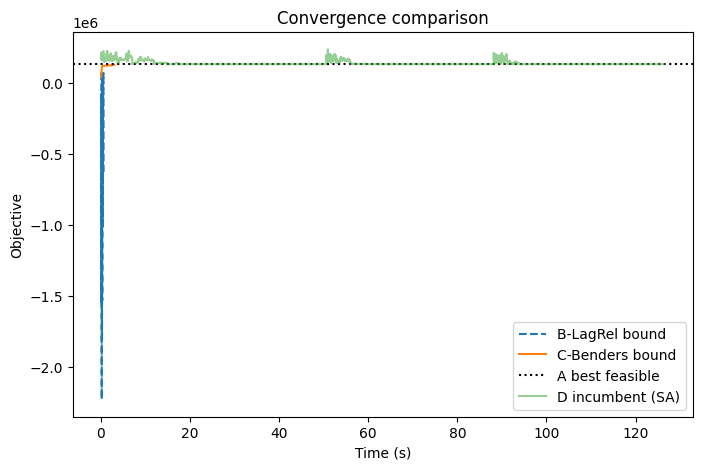

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8,5))
for kpi, style in [(kpiB, '--'), (kpiC, '-')]:
    if kpi.history:
        t, v = zip(*kpi.history)
        ax.plot(t, v, style, label=f"{kpi.model} bound")
ax.axhline(kpiA.best_feasible, color='k', linestyle=':', label='A best feasible')
if kpiD.history:
    t, v = zip(*kpiD.history)
    ax.step(t, v, where='post', alpha=0.5, label='D incumbent (SA)')
ax.set_xlabel("Time (s)"); ax.set_ylabel("Objective"); ax.legend(); ax.set_title("Convergence comparison")
plt.show()

### Network Visualization

Let's visualize the network structure of plants, satellites, and customers using the subsampled instance (`d_test`). This will help understand the relationships between these entities.

In [ ]:
!pip install networkx -q

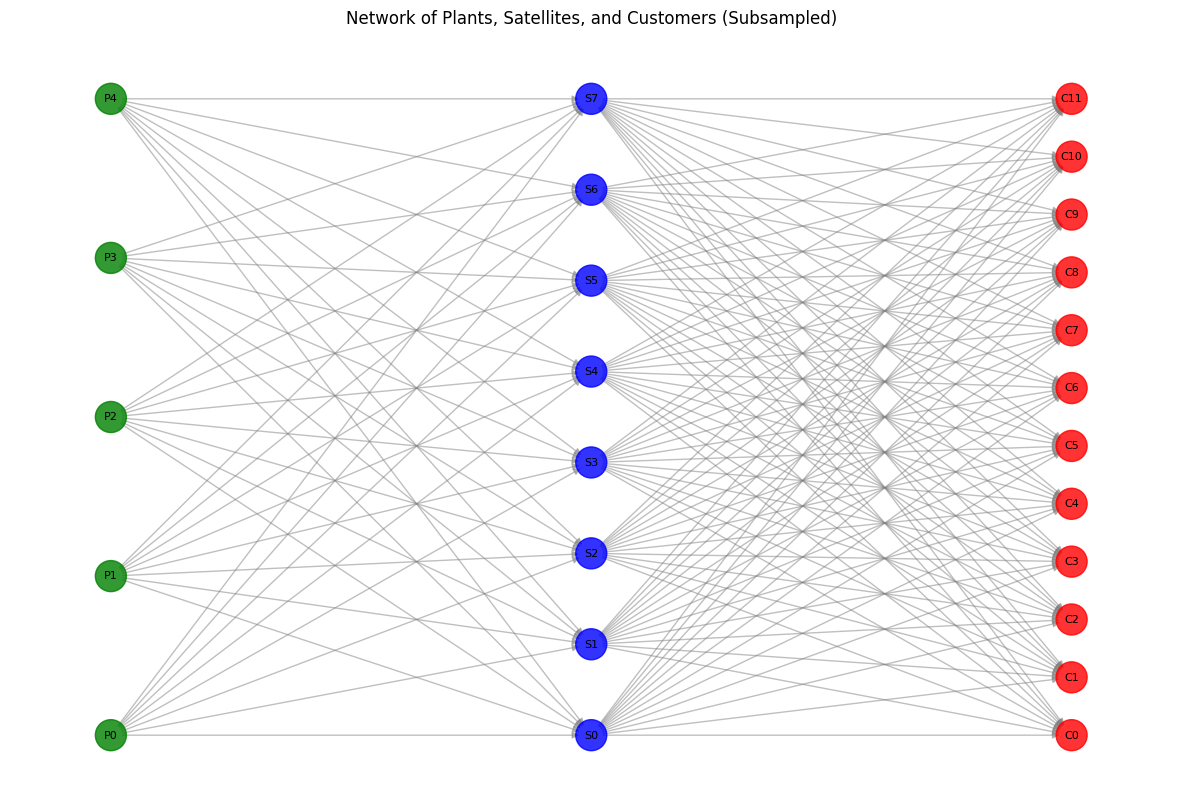

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

# Extract relevant data from d_test
I_small = d_test['I']
J_small = d_test['J']
K_small = d_test['K']

# Create a directed graph
G = nx.DiGraph()

# Manually create a position dictionary to control layout
pos = {}

# Add Plant nodes and assign positions (x=0 for plants)
for i in range(I_small):
    # Normalize y-coordinate for even spacing within the layer
    y_coord = i / (I_small - 1) if I_small > 1 else 0.5
    G.add_node(f'P{i}', type='plant')
    pos[f'P{i}'] = (0, y_coord)

# Add Satellite nodes and assign positions (x=1 for satellites)
for j in range(J_small):
    y_coord = j / (J_small - 1) if J_small > 1 else 0.5
    G.add_node(f'S{j}', type='satellite')
    pos[f'S{j}'] = (1, y_coord)

# Add Customer nodes and assign positions (x=2 for customers)
for k in range(K_small):
    y_coord = k / (K_small - 1) if K_small > 1 else 0.5
    G.add_node(f'C{k}', type='customer')
    pos[f'C{k}'] = (2, y_coord)

# Add edges from Plants to Satellites
# For simplicity, let's assume every plant can connect to every satellite in the subsampled instance.
# In a real scenario, you might add edges based on cost data or existing connections.
for i in range(I_small):
    for j in range(J_small):
        G.add_edge(f'P{i}', f'S{j}')

# Add edges from Satellites to Customers
# For simplicity, assume every satellite can connect to every customer.
for j in range(J_small):
    for k in range(K_small):
        G.add_edge(f'S{j}', f'C{k}')

# Define node colors and shapes based on type
node_colors = []
# node_shapes are implicitly handled by draw_networkx_nodes default or not used if not specified
node_labels = {}

for node in G.nodes():
    node_labels[node] = node
    if G.nodes[node]['type'] == 'plant':
        node_colors.append('green')
    elif G.nodes[node]['type'] == 'satellite':
        node_colors.append('blue')
    else:
        node_colors.append('red')

# Plotting the graph
plt.figure(figsize=(15, 10))

# Draw nodes
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=500, alpha=0.8)

# Draw edges
nx.draw_networkx_edges(G, pos, edge_color='gray', alpha=0.5, arrowsize=10)

# Draw labels for plants, satellites, and customers
plant_labels = {node: node for node in G.nodes() if G.nodes[node]['type'] == 'plant'}
satellite_labels = {node: node for node in G.nodes() if G.nodes[node]['type'] == 'satellite'}
customer_labels = {node: node for node in G.nodes() if G.nodes[node]['type'] == 'customer'}

nx.draw_networkx_labels(G, pos, labels=plant_labels, font_size=8, font_color='black')
nx.draw_networkx_labels(G, pos, labels=satellite_labels, font_size=8, font_color='black')
nx.draw_networkx_labels(G, pos, labels=customer_labels, font_size=8, font_color='black')

plt.title('Network of Plants, Satellites, and Customers (Subsampled)')
plt.axis('off') # Hide axes
plt.show()


### Opened Plants and Satellites

Based on the solutions from Model A (MILP) and Model D (Metaheuristic), here is a summary of which plants and satellites are recommended to be opened:

In [ ]:
import pandas as pd

# Extract results for Model A
opened_plants_A = [f'P{i}' for i, status in enumerate(solA['open_p']) if status == 1.0]
opened_satellites_A = [f'S{j}' for j, status in enumerate(solA['open_s']) if status == 1.0]

# Extract results for Model D
opened_plants_D = [f'P{i}' for i, status in enumerate(solD[0]) if status]
opened_satellites_D = [f'S{j}' for j, status in enumerate(solD[1]) if status]

# Create a DataFrame for comparison
summary_data = {
    'Model': ['Model A (MILP)', 'Model D (Metaheuristic)'],
    'Opened Plants': [', '.join(opened_plants_A), ', '.join(opened_plants_D)],
    'Opened Satellites': [', '.join(opened_satellites_A), ', '.join(opened_satellites_D)]
}

opened_facilities_df = pd.DataFrame(summary_data)
display(opened_facilities_df)

,Model,Opened Plants,Opened Satellites
0,Model A (MILP),P0,"S0, S1"
1,Model D (Metaheuristic),P0,"S0, S1"


### Prescriptive Nature of the Results

These results are **prescriptive** because they provide direct, actionable recommendations on *what decisions to make* to achieve the stated objective (e.g., minimizing total cost) while satisfying all constraints (e.g., customer demand, plant and satellite capacities).

Instead of just describing what *is* (descriptive analytics) or predicting what *will be* (predictive analytics), prescriptive analytics uses optimization and other techniques to suggest the *best course of action*. In this context:

*   **The Models:** The MILP (Model A), Lagrangian Relaxation (Model B), Benders Decomposition (Model C), and Metaheuristic (Model D) are all designed to find optimal or near-optimal solutions to the complex facility location problem.

*   **The Recommendation:** The output, specifically the `opened_plants` and `opened_satellites` lists, tells you exactly *which* plants and satellites to activate and utilize. These are the decisions that the model has determined to be the most cost-effective given the input data (demands, capacities, fixed costs, flow costs).

*   **Actionable Insights:** This information directly informs strategic planning. For instance, a company could use these results to decide where to build new facilities, where to expand existing ones, or which facilities to keep operational to efficiently serve customer demand.

In [ ]:
!pip install brkga-mp-ipr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.6/48.6 kB 2.5 MB/s eta 0:00:00


In [ ]:
# ============================================================
# CELL 2 — IMPORTS
# ============================================================

import numpy as np
import pandas as pd
import time
import requests
from dataclasses import dataclass

from brkga_mp_ipr.algorithm import BrkgaMpIpr
from brkga_mp_ipr.enums import (
    Sense,
    BiasFunctionType,
    PathRelinkingType,
    PathRelinkingSelection
)
from brkga_mp_ipr.types import (
    BrkgaParams,
    BaseChromosome
)

np.set_printoptions(
    precision=3,
    suppress=True
)

SEED = 2026

INSTANCE_URL = (
    "https://raw.githubusercontent.com/Matshiselan/OR-Datasets/"
    "refs/heads/master/Facility-Location/TSCFLP/MP/Mauri2021/"
    "instances/PSC1-C1-100-5.txt"
)

print("Imports successful.")

Imports successful.


In [ ]:
# ============================================================
# CELL 3 — LOAD RAW INSTANCE
# ============================================================

response = requests.get(INSTANCE_URL)
response.raise_for_status()

raw_lines = [
    line.strip()
    for line in response.text.splitlines()
    if line.strip()
]

print("Number of non-empty lines:", len(raw_lines))

header = list(map(int, raw_lines[0].split()))

I, J, K, L = header

print(f"Plants    I = {I}")
print(f"Depots    J = {J}")
print(f"Customers K = {K}")
print(f"Products  L = {L}")

Number of non-empty lines: 2201
Plants    I = 100
Depots    J = 200
Customers K = 400
Products  L = 5


In [ ]:
# ============================================================
# CELL 4 — PARSE INSTANCE
# ============================================================

rows = [
    list(map(float, line.split()))
    for line in raw_lines[1:]
]

cursor = 0

# ------------------------------------------------------------
# 1. Customer demand q[k,l]
# ------------------------------------------------------------

q = np.asarray(
    rows[cursor:cursor + K],
    dtype=np.float64
)

cursor += K

assert q.shape == (K, L), q.shape


# ------------------------------------------------------------
# 2. Plant capacity + fixed cost
#
# columns 0:L = b[i,l]
# column L    = f[i]
# ------------------------------------------------------------

plant_block = np.asarray(
    rows[cursor:cursor + I],
    dtype=np.float64
)

cursor += I

assert plant_block.shape == (I, L + 1), plant_block.shape

b = plant_block[:, :L]
f = plant_block[:, L]


# ------------------------------------------------------------
# 3. Plant → depot transportation costs
#
# 5 blocks
# each block = 100 × 200
#
# c[l,i,j]
# ------------------------------------------------------------

c = np.empty(
    (L, I, J),
    dtype=np.float64
)

for l in range(L):

    block = np.asarray(
        rows[cursor:cursor + I],
        dtype=np.float64
    )

    cursor += I

    assert block.shape == (I, J), block.shape

    c[l] = block


# ------------------------------------------------------------
# 4. Depot capacity + fixed cost
#
# columns 0:L = p[j,l]
# column L    = g[j]
# ------------------------------------------------------------

depot_block = np.asarray(
    rows[cursor:cursor + J],
    dtype=np.float64
)

cursor += J

assert depot_block.shape == (J, L + 1), depot_block.shape

p = depot_block[:, :L]
g = depot_block[:, L]


# ------------------------------------------------------------
# 5. Depot → customer transportation costs
#
# 5 blocks
# each block = 200 × 400
#
# d[l,j,k]
# ------------------------------------------------------------

d = np.empty(
    (L, J, K),
    dtype=np.float64
)

for l in range(L):

    block = np.asarray(
        rows[cursor:cursor + J],
        dtype=np.float64
    )

    cursor += J

    assert block.shape == (J, K), block.shape

    d[l] = block


# ------------------------------------------------------------
# Verify parser consumed everything
# ------------------------------------------------------------

assert cursor == len(rows), (
    f"Parser stopped at {cursor}, "
    f"but file contains {len(rows)} data lines."
)

print("Parser validation successful.")
print()
print("q:", q.shape)
print("b:", b.shape)
print("f:", f.shape)
print("c:", c.shape)
print("p:", p.shape)
print("g:", g.shape)
print("d:", d.shape)

Parser validation successful.

q: (400, 5)
b: (100, 5)
f: (100,)
c: (5, 100, 200)
p: (200, 5)
g: (200,)
d: (5, 200, 400)


In [ ]:
# ============================================================
# CELL 5 — DATA VALIDATION
# ============================================================

print("===== INSTANCE SUMMARY =====")

print(f"Plants:       {I}")
print(f"Depots:       {J}")
print(f"Customers:    {K}")
print(f"Products:     {L}")

print("\n===== TOTAL DEMAND =====")

for l in range(L):
    print(
        f"Product {l+1}: "
        f"{q[:, l].sum():,.0f}"
    )

print("\n===== TOTAL PLANT CAPACITY =====")

for l in range(L):
    print(
        f"Product {l+1}: "
        f"{b[:, l].sum():,.0f}"
    )

print("\n===== TOTAL DEPOT CAPACITY =====")

for l in range(L):
    print(
        f"Product {l+1}: "
        f"{p[:, l].sum():,.0f}"
    )

print("\n===== FIXED COSTS =====")

print(
    f"Plant fixed costs: "
    f"min={f.min():,.0f}, "
    f"mean={f.mean():,.0f}, "
    f"max={f.max():,.0f}"
)

print(
    f"Depot fixed costs: "
    f"min={g.min():,.0f}, "
    f"mean={g.mean():,.0f}, "
    f"max={g.max():,.0f}"
)

===== INSTANCE SUMMARY =====
Plants:       100
Depots:       200
Customers:    400
Products:     5

===== TOTAL DEMAND =====
Product 1: 6,023
Product 2: 6,015
Product 3: 6,028
Product 4: 6,019
Product 5: 6,033

===== TOTAL PLANT CAPACITY =====
Product 1: 20,429
Product 2: 21,180
Product 3: 21,274
Product 4: 21,429
Product 5: 20,192

===== TOTAL DEPOT CAPACITY =====
Product 1: 21,688
Product 2: 20,943
Product 3: 20,658
Product 4: 20,767
Product 5: 21,454

===== FIXED COSTS =====
Plant fixed costs: min=20,016, mean=24,667, max=29,869
Depot fixed costs: min=8,022, mean=9,969, max=12,000


In [ ]:
# ============================================================
# CELL 6 — PRECOMPUTATION
# ============================================================

# Facility efficiency measures
plant_capacity_total = b.sum(axis=1)
depot_capacity_total = p.sum(axis=1)

plant_efficiency = f / np.maximum(
    plant_capacity_total,
    1e-9
)

depot_efficiency = g / np.maximum(
    depot_capacity_total,
    1e-9
)

# Cost summaries
plant_to_depot_mean = c.mean(axis=(0, 2))
depot_to_customer_mean = d.mean(axis=(0, 2))

print("Precomputation complete.")

Precomputation complete.


In [ ]:
# ============================================================
# CELL 7 — CHROMOSOME DEFINITION
# ============================================================

PLANT_GENE_START = 0
PLANT_GENE_END = I

DEPOT_GENE_START = I
DEPOT_GENE_END = I + J

PLANT_THRESHOLD_GENE = I + J
DEPOT_THRESHOLD_GENE = I + J + 1

CHROMOSOME_SIZE = I + J + 2

print("Chromosome size:", CHROMOSOME_SIZE)

Chromosome size: 302


In [ ]:
# ============================================================
# CELL 8 — FACILITY DECODER
# ============================================================

def select_facilities(
    plant_keys,
    depot_keys,
    plant_threshold,
    depot_threshold
):
    """
    Convert random keys into open plant/depot decisions.

    Guarantees aggregate capacity feasibility for every product.
    """

    # --------------------------------------------------------
    # Initial facilities according to thresholds
    # --------------------------------------------------------

    open_plants = np.flatnonzero(
        plant_keys <= plant_threshold
    ).tolist()

    open_depots = np.flatnonzero(
        depot_keys <= depot_threshold
    ).tolist()

    # --------------------------------------------------------
    # Guarantee plant capacity feasibility
    # --------------------------------------------------------

    def plant_feasible(open_set):

        if len(open_set) == 0:
            return False

        capacity = b[open_set].sum(axis=0)

        return np.all(
            capacity + 1e-9 >= q.sum(axis=0)
        )

    if not plant_feasible(open_plants):

        remaining = [
            i
            for i in np.argsort(plant_keys)
            if i not in open_plants
        ]

        for i in remaining:

            open_plants.append(int(i))

            if plant_feasible(open_plants):
                break

    # --------------------------------------------------------
    # Guarantee depot capacity feasibility
    # --------------------------------------------------------

    def depot_feasible(open_set):

        if len(open_set) == 0:
            return False

        capacity = p[open_set].sum(axis=0)

        return np.all(
            capacity + 1e-9 >= q.sum(axis=0)
        )

    if not depot_feasible(open_depots):

        remaining = [
            j
            for j in np.argsort(depot_keys)
            if j not in open_depots
        ]

        for j in remaining:

            open_depots.append(int(j))

            if depot_feasible(open_depots):
                break

    # --------------------------------------------------------
    # Safety check
    # --------------------------------------------------------

    if not plant_feasible(open_plants):
        raise RuntimeError(
            "Unable to obtain feasible plant configuration."
        )

    if not depot_feasible(open_depots):
        raise RuntimeError(
            "Unable to obtain feasible depot configuration."
        )

    return (
        np.asarray(sorted(set(open_plants)), dtype=np.int32),
        np.asarray(sorted(set(open_depots)), dtype=np.int32)
    )

In [ ]:
# ============================================================
# CELL 9 — GREEDY TRANSPORTATION DECODER
# ============================================================

def greedy_transportation(
    open_plants,
    open_depots
):
    """
    Construct feasible x and w flows.

    Returns:
        transportation_cost
        x : plant -> depot flows
        w : depot -> customer flows
    """

    x = np.zeros(
        (L, I, J),
        dtype=np.float64
    )

    w = np.zeros(
        (L, J, K),
        dtype=np.float64
    )

    total_transport_cost = 0.0

    # --------------------------------------------------------
    # Product-by-product
    # --------------------------------------------------------

    for l in range(L):

        demand = q[:, l].copy()

        plant_remaining = b[:, l].copy()
        depot_remaining = p[:, l].copy()

        # Closed facilities have zero capacity
        plant_remaining[
            np.setdiff1d(
                np.arange(I),
                open_plants
            )
        ] = 0.0

        depot_remaining[
            np.setdiff1d(
                np.arange(J),
                open_depots
            )
        ] = 0.0

        # ====================================================
        # STAGE 2
        #
        # Customer -> depot assignment
        # ====================================================

        # Process large customers first.
        customer_order = np.argsort(
            -demand
        )

        for k in customer_order:

            remaining_demand = demand[k]

            if remaining_demand <= 1e-9:
                continue

            # Cheapest open depots for this customer
            depot_order = open_depots[
                np.argsort(
                    d[l, open_depots, k]
                )
            ]

            for j in depot_order:

                available = depot_remaining[j]

                if available <= 1e-9:
                    continue

                amount = min(
                    remaining_demand,
                    available
                )

                w[l, j, k] += amount

                depot_remaining[j] -= amount

                total_transport_cost += (
                    amount * d[l, j, k]
                )

                remaining_demand -= amount

                if remaining_demand <= 1e-9:
                    break

            if remaining_demand > 1e-7:

                raise RuntimeError(
                    f"Depot capacity failure "
                    f"for product {l}, customer {k}"
                )

        # ====================================================
        # STAGE 1
        #
        # Plant -> depot assignment
        # ====================================================

        depot_requirements = w[l].sum(axis=1)

        depot_order = np.argsort(
            -depot_requirements
        )

        for j in depot_order:

            required = depot_requirements[j]

            if required <= 1e-9:
                continue

            # Cheapest open plants for this depot
            plant_order = open_plants[
                np.argsort(
                    c[l, open_plants, j]
                )
            ]

            remaining = required

            for i in plant_order:

                available = plant_remaining[i]

                if available <= 1e-9:
                    continue

                amount = min(
                    remaining,
                    available
                )

                x[l, i, j] += amount

                plant_remaining[i] -= amount

                total_transport_cost += (
                    amount * c[l, i, j]
                )

                remaining -= amount

                if remaining <= 1e-9:
                    break

            if remaining > 1e-7:

                raise RuntimeError(
                    f"Plant capacity failure "
                    f"for product {l}, depot {j}"
                )

    return (
        total_transport_cost,
        x,
        w
    )

In [ ]:
# ============================================================
# CELL 10 — SOLUTION CONTAINER
# ============================================================

@dataclass
class MPTSCFLPSolution:

    objective: float

    fixed_plant_cost: float
    fixed_depot_cost: float

    plant_transport_cost: float
    depot_transport_cost: float

    open_plants: np.ndarray
    open_depots: np.ndarray

    x: np.ndarray
    w: np.ndarray

In [ ]:
# ============================================================
# CELL 11 — BRKGA DECODER
# ============================================================

class MPTSCFLPDecoder:

    def __init__(self):
        self.best_solution = None
        self.evaluations = 0

    def decode(
        self,
        chromosome: BaseChromosome,
        rewrite: bool
    ) -> float:

        self.evaluations += 1

        chromosome = np.asarray(
            chromosome,
            dtype=np.float64
        )

        # ----------------------------------------------------
        # Extract keys
        # ----------------------------------------------------

        plant_keys = chromosome[
            PLANT_GENE_START:PLANT_GENE_END
        ]

        depot_keys = chromosome[
            DEPOT_GENE_START:DEPOT_GENE_END
        ]

        plant_threshold = chromosome[
            PLANT_THRESHOLD_GENE
        ]

        depot_threshold = chromosome[
            DEPOT_THRESHOLD_GENE
        ]

        # ----------------------------------------------------
        # Decode facilities
        # ----------------------------------------------------

        open_plants, open_depots = select_facilities(
            plant_keys,
            depot_keys,
            plant_threshold,
            depot_threshold
        )

        # ----------------------------------------------------
        # Transportation
        # ----------------------------------------------------

        (
            transportation_cost,
            x,
            w
        ) = greedy_transportation(
            open_plants,
            open_depots
        )

        # ----------------------------------------------------
        # Fixed costs
        # ----------------------------------------------------

        fixed_plant_cost = f[
            open_plants
        ].sum()

        fixed_depot_cost = g[
            open_depots
        ].sum()

        # ----------------------------------------------------
        # Objective
        # ----------------------------------------------------

        objective = (
            fixed_plant_cost
            +
            fixed_depot_cost
            +
            transportation_cost
        )

        # ----------------------------------------------------
        # Separate transportation costs
        # ----------------------------------------------------

        plant_transport_cost = (
            x * c
        ).sum()

        depot_transport_cost = (
            w * d
        ).sum()

        # ----------------------------------------------------
        # Save best solution
        # ----------------------------------------------------

        if (
            self.best_solution is None
            or objective < self.best_solution.objective
        ):

            self.best_solution = (
                MPTSCFLPSolution(
                    objective=objective,

                    fixed_plant_cost=
                        fixed_plant_cost,

                    fixed_depot_cost=
                        fixed_depot_cost,

                    plant_transport_cost=
                        plant_transport_cost,

                    depot_transport_cost=
                        depot_transport_cost,

                    open_plants=
                        open_plants.copy(),

                    open_depots=
                        open_depots.copy(),

                    x=x.copy(),

                    w=w.copy()
                )
            )

        return float(objective)

In [ ]:
# ============================================================
# CELL 12 — TEST ONE RANDOM CHROMOSOME
# ============================================================

rng = np.random.default_rng(SEED)

test_chromosome = BaseChromosome(
    rng.random(CHROMOSOME_SIZE).tolist()
)

decoder = MPTSCFLPDecoder()

start = time.perf_counter()

test_value = decoder.decode(
    test_chromosome,
    rewrite=True
)

elapsed = time.perf_counter() - start

print(f"Test objective: {test_value:,.2f}")
print(f"Decode time:    {elapsed:.4f} seconds")

solution = decoder.best_solution

print()
print("Open plants:", len(solution.open_plants))
print("Open depots:", len(solution.open_depots))

print()
print("Fixed plant cost:",
      f"{solution.fixed_plant_cost:,.2f}")

print("Fixed depot cost:",
      f"{solution.fixed_depot_cost:,.2f}")

print("Plant → depot:",
      f"{solution.plant_transport_cost:,.2f}")

print("Depot → customer:",
      f"{solution.depot_transport_cost:,.2f}")

print("TOTAL:",
      f"{solution.objective:,.2f}")

Test objective: 5,292,411.00
Decode time:    0.0250 seconds

Open plants: 78
Open depots: 66

Fixed plant cost: 1,916,048.00
Fixed depot cost: 664,913.00
Plant → depot: 1,054,130.00
Depot → customer: 1,657,320.00
TOTAL: 5,292,411.00


In [ ]:
# ============================================================
# CELL 13 — FEASIBILITY CHECK — CORRECTED
# ============================================================

def check_solution(solution, tolerance=1e-6):

    x = solution.x
    w = solution.w

    # ========================================================
    # DIMENSION CHECKS
    # ========================================================

    assert x.shape == (L, I, J), (
        f"x has shape {x.shape}; "
        f"expected {(L, I, J)}"
    )

    assert w.shape == (L, J, K), (
        f"w has shape {w.shape}; "
        f"expected {(L, J, K)}"
    )

    assert q.shape == (K, L)
    assert b.shape == (I, L)
    assert p.shape == (J, L)

    # ========================================================
    # 1. CUSTOMER DEMAND
    #
    # w[l,j,k]
    #
    # Sum over depots j
    #
    # (L,J,K) -> (L,K)
    #
    # Transpose -> (K,L)
    #
    # Constraint:
    #
    # sum_j w[j,k,l] >= q[k,l]
    #
    # Our decoder actually satisfies equality.
    # ========================================================

    customer_flow = (
        w.sum(axis=1).T
    )

    demand_violation = np.max(
        np.abs(
            customer_flow - q
        )
    )

    # ========================================================
    # 2. DEPOT FLOW CONSERVATION
    #
    # Incoming:
    #
    # x[l,i,j]
    # sum over i
    # -> (L,J)
    #
    # Outgoing:
    #
    # w[l,j,k]
    # sum over k
    # -> (L,J)
    #
    # Constraint:
    #
    # sum_i x[i,j,l] =
    # sum_k w[j,k,l]
    # ========================================================

    plant_to_depot = (
        x.sum(axis=1)
    )

    depot_to_customer = (
        w.sum(axis=2)
    )

    flow_violation = np.max(
        np.abs(
            plant_to_depot -
            depot_to_customer
        )
    )

    # ========================================================
    # 3. PLANT CAPACITY
    #
    # x[l,i,j]
    #
    # Sum over depots j
    #
    # (L,I,J) -> (L,I)
    #
    # Transpose
    #
    # -> (I,L)
    #
    # Now it matches:
    #
    # b[i,l]
    # ========================================================

    plant_used = (
        x.sum(axis=2).T
    )

    # Explicit dimensions:
    #
    # plant_used = (I,L)
    # b          = (I,L)

    plant_capacity = np.zeros(
        (I, L),
        dtype=np.float64
    )

    # Only open plants have capacity.
    plant_capacity[
        solution.open_plants,
        :
    ] = b[
        solution.open_plants,
        :
    ]

    # Constraint:
    #
    # sum_j x[i,j,l] <= b[i,l] y_i
    #
    plant_violation = np.max(
        np.maximum(
            plant_used -
            plant_capacity,
            0.0
        )
    )

    # ========================================================
    # 4. DEPOT CAPACITY
    #
    # w[l,j,k]
    #
    # Sum over customers k
    #
    # (L,J,K) -> (L,J)
    #
    # Transpose
    #
    # -> (J,L)
    #
    # Now it matches:
    #
    # p[j,l]
    # ========================================================

    depot_used = (
        w.sum(axis=2).T
    )

    depot_capacity = np.zeros(
        (J, L),
        dtype=np.float64
    )

    depot_capacity[
        solution.open_depots,
        :
    ] = p[
        solution.open_depots,
        :
    ]

    # Constraint:
    #
    # sum_k w[j,k,l] <= p[j,l] z_j
    #
    depot_violation = np.max(
        np.maximum(
            depot_used -
            depot_capacity,
            0.0
        )
    )

    # ========================================================
    # 5. NON-NEGATIVITY
    # ========================================================

    x_negative_violation = max(
        0.0,
        -float(np.min(x))
    )

    w_negative_violation = max(
        0.0,
        -float(np.min(w))
    )

    # ========================================================
    # 6. OPEN-FACILITY CONSISTENCY
    #
    # Closed plants/depot should have zero flow.
    # ========================================================

    closed_plants = np.setdiff1d(
        np.arange(I),
        solution.open_plants
    )

    closed_depots = np.setdiff1d(
        np.arange(J),
        solution.open_depots
    )

    closed_plant_flow = (
        np.max(
            np.abs(
                plant_used[
                    closed_plants,
                    :
                ]
            )
        )
        if len(closed_plants) > 0
        else 0.0
    )

    closed_depot_flow = (
        np.max(
            np.abs(
                depot_used[
                    closed_depots,
                    :
                ]
            )
        )
        if len(closed_depots) > 0
        else 0.0
    )

    # ========================================================
    # 7. OVERALL FEASIBILITY
    # ========================================================

    feasible = (
        demand_violation <= tolerance
        and
        flow_violation <= tolerance
        and
        plant_violation <= tolerance
        and
        depot_violation <= tolerance
        and
        x_negative_violation <= tolerance
        and
        w_negative_violation <= tolerance
        and
        closed_plant_flow <= tolerance
        and
        closed_depot_flow <= tolerance
    )

    # ========================================================
    # RETURN RESULTS
    # ========================================================

    return {

        "feasible":
            feasible,

        "demand_violation":
            demand_violation,

        "flow_violation":
            flow_violation,

        "plant_capacity_violation":
            plant_violation,

        "depot_capacity_violation":
            depot_violation,

        "x_negative_violation":
            x_negative_violation,

        "w_negative_violation":
            w_negative_violation,

        "closed_plant_flow":
            closed_plant_flow,

        "closed_depot_flow":
            closed_depot_flow
    }


# ============================================================
# RUN VALIDATION
# ============================================================

validation = check_solution(
    decoder.best_solution
)

print("=" * 65)
print("MP-TSCFLP FEASIBILITY CHECK")
print("=" * 65)

for key, value in validation.items():

    if isinstance(value, bool):

        print(
            f"{key:30s}: {value}"
        )

    else:

        print(
            f"{key:30s}: {value:.10f}"
        )

MP-TSCFLP FEASIBILITY CHECK
feasible                      : 1.0000000000
demand_violation              : 0.0000000000
flow_violation                : 0.0000000000
plant_capacity_violation      : 0.0000000000
depot_capacity_violation      : 0.0000000000
x_negative_violation          : 0.0000000000
w_negative_violation          : 0.0000000000
closed_plant_flow             : 0.0000000000
closed_depot_flow             : 0.0000000000


In [ ]:
# ============================================================
# CELL 14 — BRKGA PARAMETERS
# ============================================================

params = BrkgaParams()

# Population
params.population_size = 60

# Elite population
params.elite_percentage = 0.20

# Mutants
params.mutants_percentage = 0.10

# Multi-parent mating
params.num_elite_parents = 2
params.total_parents = 3

# Stronger bias toward better parents
params.bias_type = BiasFunctionType.EXPONENTIAL

# One population initially
params.num_independent_populations = 1

# IPR parameters are defined by the API,
# but Python v0.9 does not implement path_relink().
params.pr_number_pairs = 10
params.pr_minimum_distance = 0.10
params.pr_type = PathRelinkingType.DIRECT
params.pr_selection = PathRelinkingSelection.BESTSOLUTION
params.alpha_block_size = 1.0
params.pr_percentage = 1.0

print("BRKGA parameters configured.")

BRKGA parameters configured.


In [ ]:
# ============================================================
# CELL 15 — RUN BRKGA
# ============================================================

decoder = MPTSCFLPDecoder()

brkga = BrkgaMpIpr(
    decoder=decoder,
    sense=Sense.MINIMIZE,
    seed=SEED,
    chromosome_size=CHROMOSOME_SIZE,
    params=params
)

start_time = time.perf_counter()

brkga.initialize()

initial_best = brkga.get_best_fitness()

print(
    f"Initial best: {initial_best:,.2f}"
)

# ------------------------------------------------------------
# Evolution
# ------------------------------------------------------------

NUM_GENERATIONS = 100

brkga.evolve(
    NUM_GENERATIONS
)

elapsed = time.perf_counter() - start_time

best_fitness = brkga.get_best_fitness()
best_chromosome = brkga.get_best_chromosome()

print()
print("=" * 60)
print("BRKGA RESULTS")
print("=" * 60)

print(
    f"Initial best: {initial_best:,.2f}"
)

print(
    f"Final best:   {best_fitness:,.2f}"
)

print(
    f"Runtime:      {elapsed:.2f} seconds"
)

print(
    f"Evaluations:  {decoder.evaluations:,}"
)

Initial best: 4,068,812.00

BRKGA RESULTS
Initial best: 4,068,812.00
Final best:   3,912,600.00
Runtime:      116.32 seconds
Evaluations:  4,860


In [ ]:
# ============================================================
# CELL 16 — BEST SOLUTION
# ============================================================

best_solution = decoder.best_solution

print("=" * 60)
print("BEST MP-TSCFLP SOLUTION")
print("=" * 60)

print(
    f"Objective:              "
    f"{best_solution.objective:,.2f}"
)

print(
    f"Fixed plant cost:       "
    f"{best_solution.fixed_plant_cost:,.2f}"
)

print(
    f"Fixed depot cost:       "
    f"{best_solution.fixed_depot_cost:,.2f}"
)

print(
    f"Plant → depot cost:     "
    f"{best_solution.plant_transport_cost:,.2f}"
)

print(
    f"Depot → customer cost:  "
    f"{best_solution.depot_transport_cost:,.2f}"
)

print(
    f"Open plants:            "
    f"{len(best_solution.open_plants)}"
)

print(
    f"Open depots:            "
    f"{len(best_solution.open_depots)}"
)

BEST MP-TSCFLP SOLUTION
Objective:              3,912,600.00
Fixed plant cost:       652,443.00
Fixed depot cost:       532,798.00
Plant → depot cost:     1,066,708.00
Depot → customer cost:  1,660,651.00
Open plants:            28
Open depots:            57


In [ ]:
# ============================================================
# CELL 17 — FINAL VALIDATION — CORRECTED
# ============================================================

def check_solution(solution, tolerance=1e-6):

    x = solution.x
    w = solution.w

    # ========================================================
    # Expected dimensions
    #
    # x = (L, I, J)
    # w = (L, J, K)
    # ========================================================

    assert x.shape == (L, I, J), (
        f"Unexpected x shape: {x.shape}; "
        f"expected {(L, I, J)}"
    )

    assert w.shape == (L, J, K), (
        f"Unexpected w shape: {w.shape}; "
        f"expected {(L, J, K)}"
    )

    # ========================================================
    # 1. CUSTOMER DEMAND
    #
    # w[l,j,k]
    #
    # sum over j
    #
    # result = (L,K)
    # transpose -> (K,L)
    # ========================================================

    customer_flow = w.sum(axis=1).T

    demand_violation = np.max(
        np.abs(
            customer_flow - q
        )
    )

    # ========================================================
    # 2. DEPOT FLOW CONSERVATION
    #
    # Plant -> depot:
    #
    # x[l,i,j]
    # sum over i
    # => (L,J)
    #
    # Depot -> customer:
    #
    # w[l,j,k]
    # sum over k
    # => (L,J)
    #
    # ========================================================

    plant_to_depot = x.sum(axis=1)

    depot_to_customer = w.sum(axis=2)

    flow_violation = np.max(
        np.abs(
            plant_to_depot -
            depot_to_customer
        )
    )

    # ========================================================
    # 3. PLANT CAPACITY
    #
    # x[l,i,j]
    # sum over j
    # => (L,I)
    #
    # transpose
    # => (I,L)
    # ========================================================

    plant_used = x.sum(axis=2).T

    # Capacity matrix is already:
    #
    # b[i,l] = (I,L)
    #
    plant_capacity = np.zeros(
        (I, L),
        dtype=np.float64
    )

    plant_capacity[
        solution.open_plants,
        :
    ] = b[
        solution.open_plants,
        :
    ]

    plant_violation = np.max(
        np.maximum(
            plant_used -
            plant_capacity,
            0.0
        )
    )

    # ========================================================
    # 4. DEPOT CAPACITY
    #
    # w[l,j,k]
    # sum over k
    # => (L,J)
    #
    # transpose
    # => (J,L)
    # ========================================================

    depot_used = w.sum(axis=2).T

    depot_capacity = np.zeros(
        (J, L),
        dtype=np.float64
    )

    depot_capacity[
        solution.open_depots,
        :
    ] = p[
        solution.open_depots,
        :
    ]

    depot_violation = np.max(
        np.maximum(
            depot_used -
            depot_capacity,
            0.0
        )
    )

    # ========================================================
    # 5. NONNEGATIVITY
    # ========================================================

    x_negative = max(
        0.0,
        -np.min(x)
    )

    w_negative = max(
        0.0,
        -np.min(w)
    )

    # ========================================================
    # 6. OVERALL FEASIBILITY
    # ========================================================

    feasible = (
        demand_violation <= tolerance
        and
        flow_violation <= tolerance
        and
        plant_violation <= tolerance
        and
        depot_violation <= tolerance
        and
        x_negative <= tolerance
        and
        w_negative <= tolerance
    )

    return {
        "feasible": feasible,

        "demand_violation":
            demand_violation,

        "flow_violation":
            flow_violation,

        "plant_capacity_violation":
            plant_violation,

        "depot_capacity_violation":
            depot_violation,

        "x_negative_violation":
            x_negative,

        "w_negative_violation":
            w_negative
    }


# ------------------------------------------------------------
# RUN VALIDATION
# ------------------------------------------------------------

validation = check_solution(
    best_solution
)

print("=" * 60)
print("FINAL SOLUTION FEASIBILITY")
print("=" * 60)

for key, value in validation.items():

    if isinstance(value, bool):
        print(
            f"{key:30s}: {value}"
        )

    else:
        print(
            f"{key:30s}: {value:.10f}"
        )

FINAL SOLUTION FEASIBILITY
feasible                      : True
demand_violation              : 0.0000000000
flow_violation                : 0.0000000000
plant_capacity_violation      : 0.0000000000
depot_capacity_violation      : 0.0000000000
x_negative_violation          : 0.0000000000
w_negative_violation          : 0.0000000000


In [ ]:
# ============================================================
# CELL 18 — OPEN FACILITIES
# ============================================================

open_plant_df = pd.DataFrame({
    "plant": best_solution.open_plants,
    "fixed_cost": f[
        best_solution.open_plants
    ],
    "capacity_total": b[
        best_solution.open_plants
    ].sum(axis=1)
})

open_depot_df = pd.DataFrame({
    "depot": best_solution.open_depots,
    "fixed_cost": g[
        best_solution.open_depots
    ],
    "capacity_total": p[
        best_solution.open_depots
    ].sum(axis=1)
})

print("OPEN PLANTS")
display(open_plant_df)

print("\nOPEN DEPOTS")
display(open_depot_df)

OPEN PLANTS


,plant,fixed_cost,capacity_total
0,2,22803.0,1106.0
1,7,20552.0,839.0
2,8,21602.0,1098.0
3,12,21503.0,927.0
4,17,20016.0,905.0
5,18,20293.0,1096.0
6,20,27390.0,1047.0
7,22,21225.0,1171.0
8,23,21882.0,1041.0
9,25,21259.0,1040.0



OPEN DEPOTS


,depot,fixed_cost,capacity_total
0,0,9795.0,459.0
1,2,9859.0,535.0
2,10,10758.0,518.0
3,16,8876.0,545.0
4,17,9892.0,512.0
5,19,8528.0,512.0
6,20,8063.0,438.0
7,22,10491.0,577.0
8,24,10186.0,632.0
9,28,9044.0,505.0


In [ ]:
# ============================================================
# CELL 19 — FACILITY UTILIZATION — CORRECTED
# ============================================================

# ============================================================
# FLOW USAGE
#
# x = (L, I, J)
# sum over J
# => (L,I)
# transpose
# => (I,L)
#
# w = (L,J,K)
# sum over K
# => (L,J)
# transpose
# => (J,L)
# ============================================================

plant_used = (
    best_solution.x
    .sum(axis=2)
    .T
)

depot_used = (
    best_solution.w
    .sum(axis=2)
    .T
)

# ============================================================
# INITIALIZE UTILIZATION MATRICES
# ============================================================

plant_utilization = np.zeros(
    (I, L),
    dtype=np.float64
)

depot_utilization = np.zeros(
    (J, L),
    dtype=np.float64
)

# ============================================================
# PLANT UTILIZATION
# ============================================================

plant_utilization[
    best_solution.open_plants,
    :
] = (
    plant_used[
        best_solution.open_plants,
        :
    ]
    /
    np.maximum(
        b[
            best_solution.open_plants,
            :
        ],
        1e-12
    )
)

# ============================================================
# DEPOT UTILIZATION
# ============================================================

depot_utilization[
    best_solution.open_depots,
    :
] = (
    depot_used[
        best_solution.open_depots,
        :
    ]
    /
    np.maximum(
        p[
            best_solution.open_depots,
            :
        ],
        1e-12
    )
)

# ============================================================
# DATAFRAMES
# ============================================================

plant_util_df = pd.DataFrame(
    plant_utilization,
    index=[
        f"Plant_{i}"
        for i in range(I)
    ],
    columns=[
        f"Product_{l+1}"
        for l in range(L)
    ]
)

depot_util_df = pd.DataFrame(
    depot_utilization,
    index=[
        f"Depot_{j}"
        for j in range(J)
    ],
    columns=[
        f"Product_{l+1}"
        for l in range(L)
    ]
)

# ============================================================
# SUMMARY
# ============================================================

print("=" * 60)
print("FACILITY UTILIZATION")
print("=" * 60)

print("\nAverage plant utilization by product:")

print(
    plant_util_df
    .loc[
        [
            f"Plant_{i}"
            for i in best_solution.open_plants
        ]
    ]
    .mean()
)

print("\nAverage depot utilization by product:")

print(
    depot_util_df
    .loc[
        [
            f"Depot_{j}"
            for j in best_solution.open_depots
        ]
    ]
    .mean()
)

FACILITY UTILIZATION

Average plant utilization by product:
Product_1    0.982941
Product_2    1.000000
Product_3    0.974292
Product_4    0.942565
Product_5    0.998768
dtype: float64

Average depot utilization by product:
Product_1    0.972738
Product_2    0.992615
Product_3    0.999874
Product_4    0.993548
Product_5    0.989682
dtype: float64


In [ ]:
# ============================================================
# CELL 20 — INDEPENDENT OBJECTIVE VALIDATION
# ============================================================

def calculate_objective_independently(solution):

    # Fixed facility costs
    fixed_plants = f[
        solution.open_plants
    ].sum()

    fixed_depots = g[
        solution.open_depots
    ].sum()

    # Plant -> depot transportation
    plant_depot_cost = (
        solution.x * c
    ).sum()

    # Depot -> customer transportation
    depot_customer_cost = (
        solution.w * d
    ).sum()

    total = (
        fixed_plants
        +
        fixed_depots
        +
        plant_depot_cost
        +
        depot_customer_cost
    )

    return {
        "fixed_plant_cost": fixed_plants,
        "fixed_depot_cost": fixed_depots,
        "plant_depot_cost": plant_depot_cost,
        "depot_customer_cost": depot_customer_cost,
        "total": total
    }


independent = (
    calculate_objective_independently(
        best_solution
    )
)

print("=" * 60)
print("INDEPENDENT OBJECTIVE CHECK")
print("=" * 60)

for key, value in independent.items():

    print(
        f"{key:25s}: {value:,.6f}"
    )

print()
print(
    "Stored objective:",
    f"{best_solution.objective:,.6f}"
)

print(
    "Difference:",
    f"{abs(independent['total'] - best_solution.objective):,.10f}"
)

INDEPENDENT OBJECTIVE CHECK
fixed_plant_cost         : 652,443.000000
fixed_depot_cost         : 532,798.000000
plant_depot_cost         : 1,066,708.000000
depot_customer_cost      : 1,660,651.000000
total                    : 3,912,600.000000

Stored objective: 3,912,600.000000
Difference: 0.0000000000


In [ ]:
!pip install brkga

ERROR: Could not find a version that satisfies the requirement brkga (from versions: none)
ERROR: No matching distribution found for brkga


In [ ]:
# ============================================================
# CELL 21 — EXPERIMENT
# ============================================================

def run_brkga(seed, population_size, generations):
    params = BrkgaParams()
    params.population_size = population_size
    params.elite_percentage = 0.20
    params.mutants_percentage = 0.10
    params.num_elite_parents = 2
    params.total_parents = 3
    params.bias_type = BiasFunctionType.EXPONENTIAL
    params.num_independent_populations = 1
    params.pr_number_pairs = 10
    params.pr_minimum_distance = 0.10
    params.pr_type = PathRelinkingType.DIRECT
    params.pr_selection = PathRelinkingSelection.BESTSOLUTION
    params.alpha_block_size = 1.0
    params.pr_percentage = 1.0

    decoder = MPTSCFLPDecoder() # Re-initialize decoder for each run

    brkga = BrkgaMpIpr(
        decoder=decoder,
        sense=Sense.MINIMIZE,
        seed=seed,
        chromosome_size=CHROMOSOME_SIZE,
        params=params
    )

    start_time = time.perf_counter()

    brkga.initialize()
    brkga.evolve(generations)

    elapsed = time.perf_counter() - start_time
    best_fitness = brkga.get_best_fitness()

    return {
        "seed": seed,
        "best": best_fitness,
        "runtime": elapsed,
        "evaluations": decoder.evaluations
    }

seeds = [
    101,
    202,
    303,
    404,
    505,
    606,
    707,
    808,
    909,
    1010
]

results = []

for seed in seeds:

    print(
        f"Running seed {seed}..."
    )

    result = run_brkga(
        seed=seed,
        population_size=60,
        generations=100
    )

    results.append(result)

results_df = pd.DataFrame(results)

display(results_df)

Running seed 101...
Running seed 202...
Running seed 303...
Running seed 404...
Running seed 505...
Running seed 606...
Running seed 707...
Running seed 808...
Running seed 909...
Running seed 1010...


,seed,best,runtime,evaluations
0,101,3921281.0,101.619569,4860
1,202,3915085.0,104.577263,4860
2,303,3914801.0,102.642626,4860
3,404,3916310.0,103.337881,4860
4,505,3920748.0,103.078140,4860
5,606,3924276.0,102.813206,4860
6,707,3911454.0,102.377219,4860
7,808,3899138.0,100.921809,4860
8,909,3928941.0,99.125035,4860
9,1010,3926102.0,101.692566,4860


In [ ]:
# ============================================================
# CELL 22 — BRKGA SUMMARY
# ============================================================

summary = pd.DataFrame({
    "Metric": [
        "Best",
        "Worst",
        "Mean",
        "Median",
        "Std Dev",
        "Mean Runtime"
    ],

    "Value": [
        results_df["best"].min(),
        results_df["best"].max(),
        results_df["best"].mean(),
        results_df["best"].median(),
        results_df["best"].std(),
        results_df["runtime"].mean()
    ]
})

display(summary)

,Metric,Value
0,Best,3.899138e+06
1,Worst,3.928941e+06
2,Mean,3.917814e+06
3,Median,3.918529e+06
4,Std Dev,8.582393e+03
5,Mean Runtime,1.022185e+02


In [ ]:
# ============================================================
# CELL 23 — CONVERGENCE HISTORY
# ============================================================

def run_with_history(
    seed=2026,
    population_size=60,
    generations=100
):

    params = BrkgaParams()

    params.population_size = population_size
    params.elite_percentage = 0.20
    params.mutants_percentage = 0.10
    params.num_elite_parents = 2
    params.total_parents = 3
    params.bias_type = (
        BiasFunctionType.EXPONENTIAL
    )
    params.num_independent_populations = 1

    decoder = MPTSCFLPDecoder()

    algorithm = BrkgaMpIpr(
        decoder=decoder,
        sense=Sense.MINIMIZE,
        seed=seed,
        chromosome_size=CHROMOSOME_SIZE,
        params=params
    )

    algorithm.initialize()

    history = [
        algorithm.get_best_fitness()
    ]

    for generation in range(
        generations
    ):

        algorithm.evolve(1)

        history.append(
            algorithm.get_best_fitness()
        )

    return np.asarray(history)

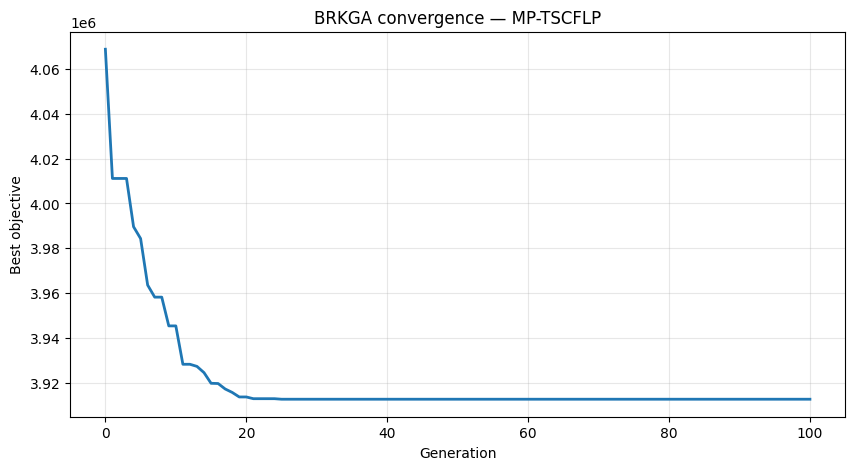

In [ ]:
# ============================================================
# CELL 24 — PLOT CONVERGENCE
# ============================================================

import matplotlib.pyplot as plt

history = run_with_history(
    seed=2026,
    population_size=60,
    generations=100
)

plt.figure(figsize=(10, 5))

plt.plot(
    history,
    linewidth=2
)

plt.xlabel("Generation")
plt.ylabel("Best objective")
plt.title(
    "BRKGA convergence — MP-TSCFLP"
)

plt.grid(alpha=0.3)

plt.show()

Optimizing for 100 Plants, 200 Satellites, 400 Customers, 5 Products...
Initializing Exact LP Solver (this will take longer per generation)...
Generation 0 | Best Fitness: 4,677,089.00
Generation 1 | Best Fitness: 4,666,243.00
Generation 2 | Best Fitness: 4,568,157.00
Generation 3 | Best Fitness: 4,450,020.00
Generation 4 | Best Fitness: 4,369,502.00
Generation 5 | Best Fitness: 4,322,071.00
Generation 6 | Best Fitness: 4,312,896.00
Generation 7 | Best Fitness: 4,304,666.00
Generation 8 | Best Fitness: 4,304,666.00
Generation 9 | Best Fitness: 4,285,979.00

Optimization finished in 524.20 seconds.
Final Objective Value: 4,285,979.00
Open Plants: 29 / 100
Open Satellites: 88 / 200


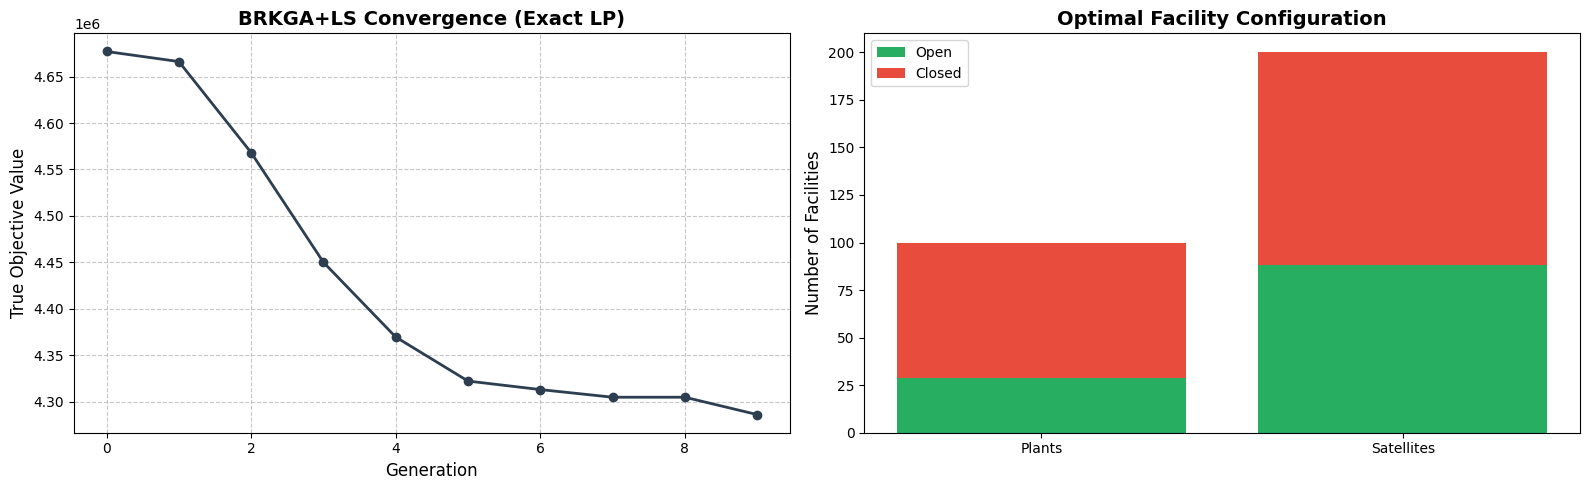

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import requests
import time
from scipy.optimize import linprog
from scipy.sparse import lil_matrix

# ==========================================
# 1. DATA PARSING & INITIALIZATION
# ==========================================
def load_and_parse_instance(url):
    response = requests.get(url)
    tokens = response.text.split()
    token_idx = 0

    def next_token():
        nonlocal token_idx
        val = float(tokens[token_idx])
        token_idx += 1
        return val

    # Parse Dimensions
    I = int(next_token())
    J = int(next_token())
    K = int(next_token())
    L = int(next_token())

    # Parse Customer Demands
    q = np.zeros((K, L))
    for k in range(K):
        for l in range(L):
            q[k, l] = next_token()

    # Parse Plant Capacities and Fixed Costs
    b = np.zeros((I, L))
    f = np.zeros(I)
    for i in range(I):
        for l in range(L):
            b[i, l] = next_token()
        f[i] = next_token()

    # Parse Plant-to-Satellite Flow Costs
    c = np.zeros((I, J, L))
    for l in range(L):
        for i in range(I):
            for j in range(J):
                c[i, j, l] = next_token()

    # Parse Satellite Capacities and Fixed Costs
    p = np.zeros((J, L))
    g = np.zeros(J)
    for j in range(J):
        for l in range(L):
            p[j, l] = next_token()
        g[j] = next_token()

    # Parse Satellite-to-Customer Flow Costs
    d = np.zeros((J, K, L))
    for l in range(L):
        for j in range(J):
            for k in range(K):
                d[j, k, l] = next_token()

    return {
        'I': I, 'J': J, 'K': K, 'L': L,
        'q': q, 'b': b, 'f': f, 'c': c, 'p': p, 'g': g, 'd': d
    }

# ==========================================
# 2. BRKGA DECODER WITH EXACT LP SOLVER
# ==========================================
def decode(chromosome, data):
    I, J, K, L = data['I'], data['J'], data['K'], data['L']

    # Threshold random keys to binary decisions
    y = (chromosome[:I] > 0.5).astype(int)
    z = (chromosome[I:I+J] > 0.5).astype(int)

    # Ensure at least one plant and one satellite is open
    if y.sum() == 0: y[np.argmax(chromosome[:I])] = 1
    if z.sum() == 0: z[np.argmax(chromosome[I:I+J])] = 1

    fixed_cost = np.sum(data['f'] * y) + np.sum(data['g'] * z)
    routing_cost = 0

    num_x = I * J
    num_w = J * K
    total_vars = num_x + num_w
    num_cons = K + J + I + J  # Demand + Flow + Plant Cap + Sat Cap

    # Solve exact routing for each product independently
    for l in range(L):
        c_cost = np.concatenate([data['c'][:, :, l].flatten(), data['d'][:, :, l].flatten()])

        # Use sparse matrices to avoid memory exhaustion
        A_ub = lil_matrix((num_cons, total_vars))
        b_ub = np.zeros(num_cons)

        row = 0

        # 1. Demand Constraints: sum_j w_jkl >= q_kl -> -sum_j w_jkl <= -q_kl
        for k in range(K):
            for j in range(J):
                A_ub[row, num_x + j*K + k] = -1
            b_ub[row] = -data['q'][k, l]
            row += 1

        # 2. Flow Conservation: sum_i x_ijl - sum_k w_jkl >= 0 -> -sum_i x_ijl + sum_k w_jkl <= 0
        for j in range(J):
            for i in range(I):
                A_ub[row, i*J + j] = -1
            for k in range(K):
                A_ub[row, num_x + j*K + k] = 1
            b_ub[row] = 0
            row += 1

        # 3. Plant Capacity Constraints: sum_j x_ijl <= b_il * y_i
        for i in range(I):
            for j in range(J):
                A_ub[row, i*J + j] = 1
            b_ub[row] = data['b'][i, l] * y[i]
            row += 1

        # 4. Satellite Capacity Constraints: sum_k w_jkl <= p_jl * z_j
        for j in range(J):
            for k in range(K):
                A_ub[row, num_x + j*K + k] = 1
            b_ub[row] = data['p'][j, l] * z[j]
            row += 1

        # Convert to CSR format for fast solving
        res = linprog(c_cost, A_ub=A_ub.tocsr(), b_ub=b_ub, bounds=(0, None), method='highs')

        if not res.success:
            return 1e12, y, z  # Return heavy penalty if configuration is physically infeasible

        routing_cost += res.fun

    return fixed_cost + routing_cost, y, z

# ==========================================
# 3. LOCAL SEARCH (+LS)
# ==========================================
def local_search(chromosome, data, current_fitness):
    best_chrom = chromosome.copy()
    best_fit = current_fitness

    for _ in range(3): # Reduced flips to save LP compute time
        idx = np.random.randint(len(chromosome))
        test_chrom = best_chrom.copy()
        test_chrom[idx] = 1.0 - test_chrom[idx]

        fit, _, _ = decode(test_chrom, data)
        if fit < best_fit:
            best_fit = fit
            best_chrom = test_chrom

    return best_chrom, best_fit

# ==========================================
# 4. BRKGA MAIN LOOP
# ==========================================
def run_brkga_ls(data, pop_size=10, max_gen=10, elite_pct=0.2, mutant_pct=0.1, rho_e=0.7):
    chrom_size = data['I'] + data['J']
    num_elite = int(pop_size * elite_pct)
    num_mutants = int(pop_size * mutant_pct)

    population = np.random.rand(pop_size, chrom_size)
    fitness_history = []

    for gen in range(max_gen):
        fitnesses = np.array([decode(ind, data)[0] for ind in population])

        sort_idx = np.argsort(fitnesses)
        population = population[sort_idx]
        fitnesses = fitnesses[sort_idx]

        # Only apply Local Search if the elite solution is feasible
        if fitnesses[0] < 1e11:
            ls_chrom, ls_fit = local_search(population[0], data, fitnesses[0])
            if ls_fit < fitnesses[0]:
                population[0] = ls_chrom
                fitnesses[0] = ls_fit

        best_fit = fitnesses[0]
        fitness_history.append(best_fit)

        print(f"Generation {gen} | Best Fitness: {best_fit:,.2f}")

        new_population = np.zeros_like(population)
        new_population[:num_elite] = population[:num_elite]
        new_population[num_elite:num_elite+num_mutants] = np.random.rand(num_mutants, chrom_size)

        for i in range(num_elite + num_mutants, pop_size):
            elite_parent = population[np.random.randint(0, max(1, num_elite))]
            non_elite_parent = population[np.random.randint(num_elite, pop_size)]
            mask = np.random.rand(chrom_size) < rho_e
            new_population[i] = np.where(mask, elite_parent, non_elite_parent)

        population = new_population

    best_chrom = population[0]
    best_fitness, best_y, best_z = decode(best_chrom, data)
    return best_fitness, best_y, best_z, fitness_history

# ==========================================
# 5. EXECUTION & VISUALIZATION
# ==========================================
if __name__ == "__main__":
    url = 'https://raw.githubusercontent.com/Matshiselan/OR-Datasets/refs/heads/master/Facility-Location/TSCFLP/MP/Mauri2021/instances/PSC1-C1-100-5.txt'
    data = load_and_parse_instance(url)

    print(f"Optimizing for {data['I']} Plants, {data['J']} Satellites, {data['K']} Customers, {data['L']} Products...")
    print("Initializing Exact LP Solver (this will take longer per generation)...")

    start_time = time.time()
    # Pop_size and max_gen reduced for testing. Increase these for final production runs.
    best_fit, best_y, best_z, history = run_brkga_ls(data, pop_size=10, max_gen=10)

    print(f"\nOptimization finished in {time.time() - start_time:.2f} seconds.")
    print(f"Final Objective Value: {best_fit:,.2f}")
    print(f"Open Plants: {best_y.sum()} / {data['I']}")
    print(f"Open Satellites: {best_z.sum()} / {data['J']}")

    # Plotting
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    axes[0].plot(history, color='#2c3e50', linewidth=2, marker='o')
    axes[0].set_title('BRKGA+LS Convergence (Exact LP)', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Generation', fontsize=12)
    axes[0].set_ylabel('True Objective Value', fontsize=12)
    axes[0].grid(True, linestyle='--', alpha=0.7)

    facilities = ['Plants', 'Satellites']
    opened = [best_y.sum(), best_z.sum()]
    closed = [data['I'] - best_y.sum(), data['J'] - best_z.sum()]

    axes[1].bar(facilities, opened, label='Open', color='#27ae60')
    axes[1].bar(facilities, closed, bottom=opened, label='Closed', color='#e74c3c')
    axes[1].set_title('Optimal Facility Configuration', fontsize=14, fontweight='bold')
    axes[1].set_ylabel('Number of Facilities', fontsize=12)
    axes[1].legend()

    plt.tight_layout()
    plt.show()

To make a full-scale run feasible without waiting half a day, we need to optimize how the algorithm handles those 8.5-second LP evaluations. There are two standard ways to drastically cut down the runtime of a GA+LP hybrid:
* Memoization (Caching): As a genetic algorithm converges, it frequently generates identical binary configurations ($y$ and $z$) through elitism and crossover. By hashing the binary arrays and storing their LP results in a dictionary, the algorithm can instantly look up the cost of any previously seen network instead of resolving the LP from scratch.
* Multiprocessing: Because evaluating one chromosome does not depend on the others, the population evaluation step is "embarrassingly parallel." We can distribute the LP solves across all the CPU cores on your machine simultaneously.

Multiprocess

Optimizing for 100 Plants, 200 Satellites, 400 Customers, 5 Products...
Initializing Exact LP Solver with Multiprocessing...
Generation 0 | Best Fitness: 4,828,114.00
Generation 1 | Best Fitness: 4,792,255.00
Generation 2 | Best Fitness: 4,706,780.00
Generation 3 | Best Fitness: 4,662,327.00
Generation 4 | Best Fitness: 4,603,079.00
Generation 5 | Best Fitness: 4,578,509.00
Generation 6 | Best Fitness: 4,543,519.00
Generation 7 | Best Fitness: 4,501,337.00
Generation 8 | Best Fitness: 4,436,077.00
Generation 9 | Best Fitness: 4,397,072.00

Optimization finished in 493.92 seconds.
Final Objective Value: 4,397,072.00
Open Plants: 35 / 100
Open Satellites: 85 / 200


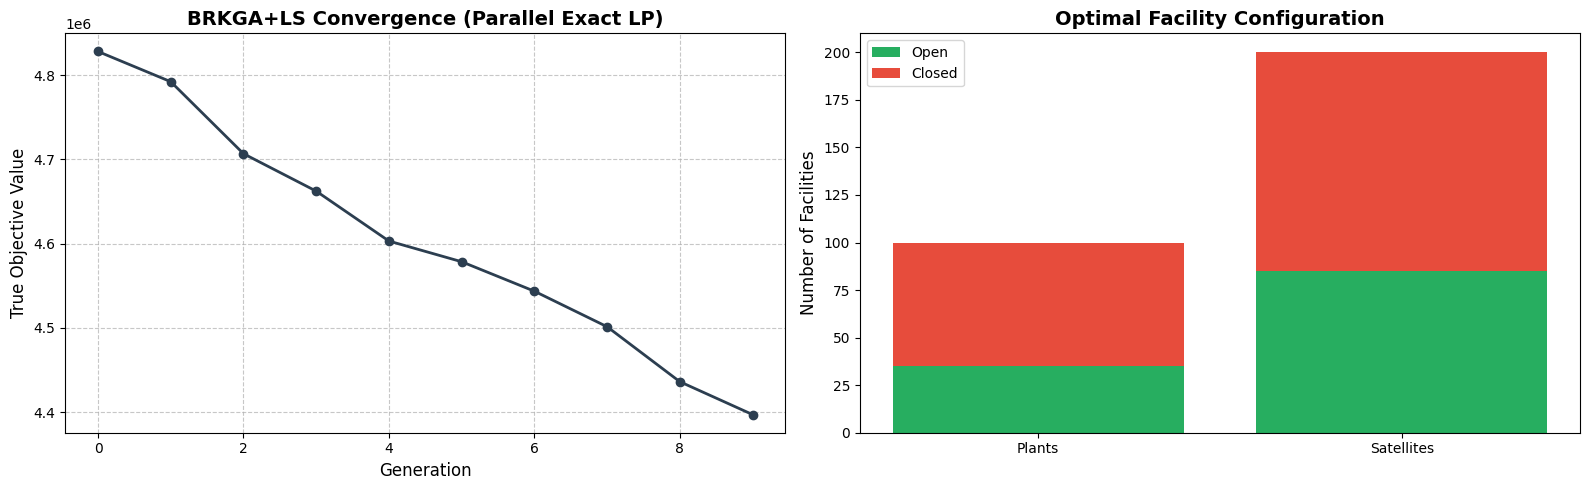

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import requests
import time
import concurrent.futures
from functools import partial
from scipy.optimize import linprog
from scipy.sparse import lil_matrix

# ==========================================
# 1. DATA PARSING & INITIALIZATION
# ==========================================
def load_and_parse_instance(url):
    response = requests.get(url)
    tokens = response.text.split()
    token_idx = 0

    def next_token():
        nonlocal token_idx
        val = float(tokens[token_idx])
        token_idx += 1
        return val

    I = int(next_token())
    J = int(next_token())
    K = int(next_token())
    L = int(next_token())

    q = np.zeros((K, L))
    for k in range(K):
        for l in range(L):
            q[k, l] = next_token()

    b = np.zeros((I, L))
    f = np.zeros(I)
    for i in range(I):
        for l in range(L):
            b[i, l] = next_token()
        f[i] = next_token()

    c = np.zeros((I, J, L))
    for l in range(L):
        for i in range(I):
            for j in range(J):
                c[i, j, l] = next_token()

    p = np.zeros((J, L))
    g = np.zeros(J)
    for j in range(J):
        for l in range(L):
            p[j, l] = next_token()
        g[j] = next_token()

    d = np.zeros((J, K, L))
    for l in range(L):
        for j in range(J):
            for k in range(K):
                d[j, k, l] = next_token()

    return {
        'I': I, 'J': J, 'K': K, 'L': L,
        'q': q, 'b': b, 'f': f, 'c': c, 'p': p, 'g': g, 'd': d
    }

# ==========================================
# 2. EXACT LP DECODER
# ==========================================
def decode(chromosome, data):
    I, J, K, L = data['I'], data['J'], data['K'], data['L']

    y = (chromosome[:I] > 0.5).astype(int)
    z = (chromosome[I:I+J] > 0.5).astype(int)

    if y.sum() == 0: y[np.argmax(chromosome[:I])] = 1
    if z.sum() == 0: z[np.argmax(chromosome[I:I+J])] = 1

    fixed_cost = np.sum(data['f'] * y) + np.sum(data['g'] * z)
    routing_cost = 0

    num_x = I * J
    num_w = J * K
    total_vars = num_x + num_w
    num_cons = K + J + I + J

    for l in range(L):
        c_cost = np.concatenate([data['c'][:, :, l].flatten(), data['d'][:, :, l].flatten()])

        A_ub = lil_matrix((num_cons, total_vars))
        b_ub = np.zeros(num_cons)
        row = 0

        for k in range(K):
            for j in range(J):
                A_ub[row, num_x + j*K + k] = -1
            b_ub[row] = -data['q'][k, l]
            row += 1

        for j in range(J):
            for i in range(I):
                A_ub[row, i*J + j] = -1
            for k in range(K):
                A_ub[row, num_x + j*K + k] = 1
            b_ub[row] = 0
            row += 1

        for i in range(I):
            for j in range(J):
                A_ub[row, i*J + j] = 1
            b_ub[row] = data['b'][i, l] * y[i]
            row += 1

        for j in range(J):
            for k in range(K):
                A_ub[row, num_x + j*K + k] = 1
            b_ub[row] = data['p'][j, l] * z[j]
            row += 1

        res = linprog(c_cost, A_ub=A_ub.tocsr(), b_ub=b_ub, bounds=(0, None), method='highs')

        if not res.success:
            return 1e12, y, z

        routing_cost += res.fun

    return fixed_cost + routing_cost, y, z

# ==========================================
# 3. MULTIPROCESSING HELPERS & LOCAL SEARCH
# ==========================================
def eval_fitness(chromosome, data):
    """Wrapper function required for ProcessPoolExecutor pickling."""
    fit, _, _ = decode(chromosome, data)
    return fit

def local_search(chromosome, data, current_fitness):
    best_chrom = chromosome.copy()
    best_fit = current_fitness

    for _ in range(3):
        idx = np.random.randint(len(chromosome))
        test_chrom = best_chrom.copy()
        test_chrom[idx] = 1.0 - test_chrom[idx]

        fit, _, _ = decode(test_chrom, data)
        if fit < best_fit:
            best_fit = fit
            best_chrom = test_chrom

    return best_chrom, best_fit

# ==========================================
# 4. BRKGA MAIN LOOP (PARALLELIZED)
# ==========================================
def run_brkga_ls_parallel(data, pop_size=10, max_gen=10, elite_pct=0.2, mutant_pct=0.1, rho_e=0.7):
    chrom_size = data['I'] + data['J']
    num_elite = int(pop_size * elite_pct)
    num_mutants = int(pop_size * mutant_pct)

    population = np.random.rand(pop_size, chrom_size)
    fitness_history = []

    # Initialize the Process Pool
    # max_workers=None defaults to the number of processors on the machine
    with concurrent.futures.ProcessPoolExecutor() as executor:
        for gen in range(max_gen):

            # --- PARALLEL EVALUATION ---
            # partial() locks in the 'data' dictionary so executor.map only passes the chromosomes
            eval_func = partial(eval_fitness, data=data)
            fitnesses = np.array(list(executor.map(eval_func, population)))

            sort_idx = np.argsort(fitnesses)
            population = population[sort_idx]
            fitnesses = fitnesses[sort_idx]

            if fitnesses[0] < 1e11:
                ls_chrom, ls_fit = local_search(population[0], data, fitnesses[0])
                if ls_fit < fitnesses[0]:
                    population[0] = ls_chrom
                    fitnesses[0] = ls_fit

            best_fit = fitnesses[0]
            fitness_history.append(best_fit)

            print(f"Generation {gen} | Best Fitness: {best_fit:,.2f}")

            new_population = np.zeros_like(population)
            new_population[:num_elite] = population[:num_elite]
            new_population[num_elite:num_elite+num_mutants] = np.random.rand(num_mutants, chrom_size)

            for i in range(num_elite + num_mutants, pop_size):
                elite_parent = population[np.random.randint(0, max(1, num_elite))]
                non_elite_parent = population[np.random.randint(num_elite, pop_size)]
                mask = np.random.rand(chrom_size) < rho_e
                new_population[i] = np.where(mask, elite_parent, non_elite_parent)

            population = new_population

    best_chrom = population[0]
    best_fitness, best_y, best_z = decode(best_chrom, data)
    return best_fitness, best_y, best_z, fitness_history

# ==========================================
# 5. EXECUTION & VISUALIZATION
# ==========================================
if __name__ == "__main__":
    url = 'https://raw.githubusercontent.com/Matshiselan/OR-Datasets/refs/heads/master/Facility-Location/TSCFLP/MP/Mauri2021/instances/PSC1-C1-100-5.txt'
    data = load_and_parse_instance(url)

    print(f"Optimizing for {data['I']} Plants, {data['J']} Satellites, {data['K']} Customers, {data['L']} Products...")
    print("Initializing Exact LP Solver with Multiprocessing...")

    start_time = time.time()

    # Run the parallel version
    best_fit, best_y, best_z, history = run_brkga_ls_parallel(data, pop_size=10, max_gen=10)

    print(f"\nOptimization finished in {time.time() - start_time:.2f} seconds.")
    print(f"Final Objective Value: {best_fit:,.2f}")
    print(f"Open Plants: {best_y.sum()} / {data['I']}")
    print(f"Open Satellites: {best_z.sum()} / {data['J']}")

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    axes[0].plot(history, color='#2c3e50', linewidth=2, marker='o')
    axes[0].set_title('BRKGA+LS Convergence (Parallel Exact LP)', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Generation', fontsize=12)
    axes[0].set_ylabel('True Objective Value', fontsize=12)
    axes[0].grid(True, linestyle='--', alpha=0.7)

    facilities = ['Plants', 'Satellites']
    opened = [best_y.sum(), best_z.sum()]
    closed = [data['I'] - best_y.sum(), data['J'] - best_z.sum()]

    axes[1].bar(facilities, opened, label='Open', color='#27ae60')
    axes[1].bar(facilities, closed, bottom=opened, label='Closed', color='#e74c3c')
    axes[1].set_title('Optimal Facility Configuration', fontsize=14, fontweight='bold')
    axes[1].set_ylabel('Number of Facilities', fontsize=12)
    axes[1].legend()

    plt.tight_layout()
    plt.show()

Random seed: 42
https://raw.githubusercontent.com/Matshiselan/OR-Datasets/refs/heads/master/Facility-Location/TSCFLP/MP/Mauri2021/instances/PSC1-C1-100-5.txt
MP-TSCFLP INSTANCE
Plants      : 100
Depots      : 200
Customers   : 400
Products    : 5

Shapes
q: (400, 5)
b: (100, 5)
c: (100, 200, 5)
p: (200, 5)
d: (200, 400, 5)

DATA SANITY CHECK
Total demand by product:
[6023. 6015. 6028. 6019. 6033.]

Total plant capacity by product:
[20429. 21180. 21274. 21429. 20192.]

Total depot capacity by product:
[21688. 20943. 20658. 20767. 21454.]

Plant capacity sufficient: True
Depot capacity sufficient: True
LP STRUCTURE
x variables : 20000
w variables : 80000
total vars  : 100000
constraints  : 900

A_UB shape: (900, 100000)
A_UB nonzeros: 280000
BRKGA PARAMETERS
Population: 50
Generations: 100
Elite %: 0.2
Mutant %: 0.1
Elite inheritance: 0.7
Local search every: 5
Local search candidates: 15
STARTING BRKGA + EXACT LP
Generation    0 | Current: 4,000,457.00 | Global: 4,000,457.00 | Time: 2374

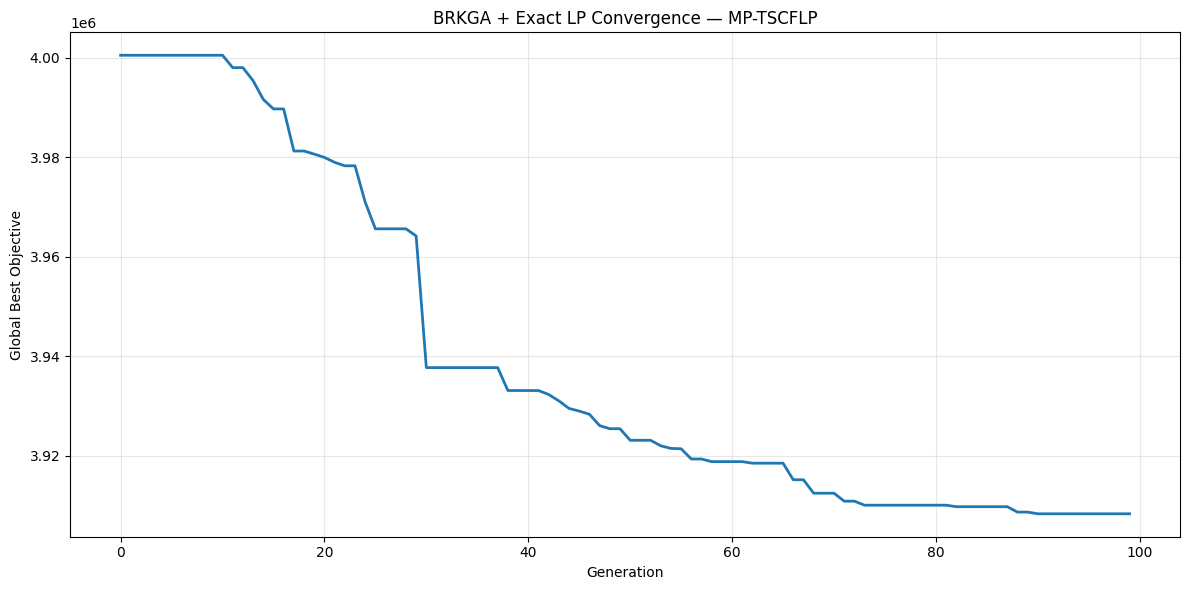

FACILITY CONFIGURATION
Plants opened: 30
Plants closed: 70

Depots opened: 57
Depots closed: 143

Open plants:
[ 2  5  7 12 15 17 18 19 22 23 24 25 28 32 34 36 43 47 52 57 59 61 65 67
 77 78 86 89 91 92]

Open depots:
[  2   3   6   8  16  19  25  26  28  30  38  43  48  54  55  56  57  58
  60  64  65  69  71  72  73  74  76  77  81  85  86  94  96 107 108 110
 111 114 116 117 118 119 122 125 127 130 141 144 146 150 151 154 156 164
 169 174 175]


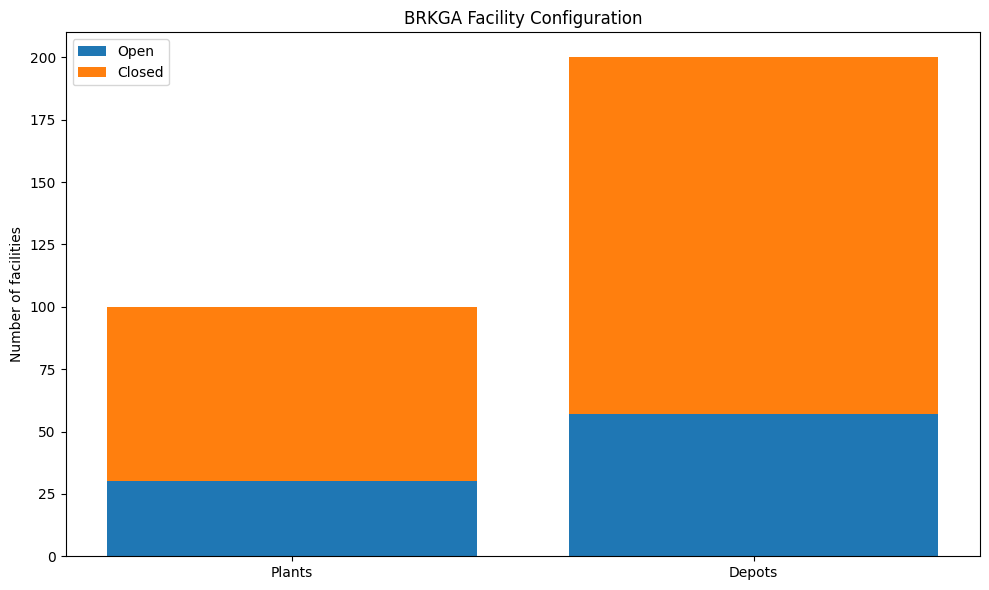

PLANT UTILIZATION
Product_1    0.992619
Product_2    0.980130
Product_3    0.945717
Product_4    0.904281
Product_5    0.982421
dtype: float64

DEPOT UTILIZATION
Product_1    0.990653
Product_2    0.998222
Product_3    0.988192
Product_4    0.978879
Product_5    0.959038
dtype: float64

TOP OPEN PLANTS BY UTILIZATION
    Plant  Open  Fixed_Cost  Total_Capacity  Total_Used  Utilization
15     15     1     23312.0           955.0       955.0     1.000000
12     12     1     21503.0           927.0       927.0     1.000000
17     17     1     20016.0           905.0       905.0     1.000000
18     18     1     20293.0          1096.0      1096.0     1.000000
24     24     1     26141.0           976.0       976.0     1.000000
89     89     1     20032.0          1014.0      1014.0     1.000000
65     65     1     21713.0          1080.0      1080.0     1.000000
67     67     1     22549.0          1047.0      1047.0     1.000000
78     78     1     24551.0          1210.0      1210.0     

In [ ]:
# ============================================================
# MP-TSCFLP
# IMPROVED BRKGA + EXACT TRANSPORTATION LP
#
# Instance:
# PSC1-C1-100-5
#
# Main improvements over previous version:
#
# 1. Exact LP decoder
# 2. Sparse constraint matrix constructed ONCE
# 3. Random-key facility ranking
# 4. Random keys determine facility priority
# 5. Separate genes control number of open plants/depots
# 6. Global-best preservation
# 7. Elite / non-elite biased crossover
# 8. Mutation
# 9. Local search
# 10. Detailed validation
# 11. Objective decomposition
# 12. Multiprocessing
#
# ============================================================


# ============================================================
# CELL 1 — IMPORTS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import requests
import time
import os

from dataclasses import dataclass
from scipy.optimize import linprog
from scipy.sparse import lil_matrix

import concurrent.futures
from functools import partial


# ============================================================
# CELL 2 — RANDOM SEED
# ============================================================

SEED = 42

np.random.seed(SEED)

print("Random seed:", SEED)


# ============================================================
# CELL 3 — INSTANCE URL
# ============================================================

URL = (
    "https://raw.githubusercontent.com/"
    "Matshiselan/OR-Datasets/"
    "refs/heads/master/"
    "Facility-Location/TSCFLP/MP/Mauri2021/"
    "instances/PSC1-C1-100-5.txt"
)

print(URL)


# ============================================================
# CELL 4 — DATA PARSING
# ============================================================

def load_and_parse_instance(url):

    response = requests.get(
        url,
        timeout=60
    )

    response.raise_for_status()

    tokens = response.text.split()

    idx = 0

    def next_value():

        nonlocal idx

        value = float(tokens[idx])

        idx += 1

        return value

    # --------------------------------------------------------
    # Dimensions
    # --------------------------------------------------------

    I = int(next_value())
    J = int(next_value())
    K = int(next_value())
    L = int(next_value())

    # --------------------------------------------------------
    # Customer demand
    #
    # q[k,l]
    # --------------------------------------------------------

    q = np.zeros(
        (K, L),
        dtype=np.float64
    )

    for k in range(K):

        for l in range(L):

            q[k, l] = next_value()

    # --------------------------------------------------------
    # Plant capacity and fixed cost
    #
    # b[i,l]
    # f[i]
    # --------------------------------------------------------

    b = np.zeros(
        (I, L),
        dtype=np.float64
    )

    f = np.zeros(
        I,
        dtype=np.float64
    )

    for i in range(I):

        for l in range(L):

            b[i, l] = next_value()

        f[i] = next_value()

    # --------------------------------------------------------
    # Plant -> depot transportation costs
    #
    # c[i,j,l]
    # --------------------------------------------------------

    c = np.zeros(
        (I, J, L),
        dtype=np.float64
    )

    for l in range(L):

        for i in range(I):

            for j in range(J):

                c[i, j, l] = next_value()

    # --------------------------------------------------------
    # Depot capacity and fixed cost
    #
    # p[j,l]
    # g[j]
    # --------------------------------------------------------

    p = np.zeros(
        (J, L),
        dtype=np.float64
    )

    g = np.zeros(
        J,
        dtype=np.float64
    )

    for j in range(J):

        for l in range(L):

            p[j, l] = next_value()

        g[j] = next_value()

    # --------------------------------------------------------
    # Depot -> customer transportation costs
    #
    # d[j,k,l]
    # --------------------------------------------------------

    d = np.zeros(
        (J, K, L),
        dtype=np.float64
    )

    for l in range(L):

        for j in range(J):

            for k in range(K):

                d[j, k, l] = next_value()

    return {
        "I": I,
        "J": J,
        "K": K,
        "L": L,
        "q": q,
        "b": b,
        "f": f,
        "c": c,
        "p": p,
        "g": g,
        "d": d
    }


# ============================================================
# CELL 5 — LOAD DATA
# ============================================================

data = load_and_parse_instance(URL)

I = data["I"]
J = data["J"]
K = data["K"]
L = data["L"]

q = data["q"]
b = data["b"]
f = data["f"]
c = data["c"]
p = data["p"]
g = data["g"]
d = data["d"]

print("=" * 70)
print("MP-TSCFLP INSTANCE")
print("=" * 70)

print(f"Plants      : {I}")
print(f"Depots      : {J}")
print(f"Customers   : {K}")
print(f"Products    : {L}")

print()
print("Shapes")

print("q:", q.shape)
print("b:", b.shape)
print("c:", c.shape)
print("p:", p.shape)
print("d:", d.shape)


# ============================================================
# CELL 6 — SANITY CHECK DATA
# ============================================================

print()
print("=" * 70)
print("DATA SANITY CHECK")
print("=" * 70)

print("Total demand by product:")

print(
    q.sum(axis=0)
)

print()

print("Total plant capacity by product:")

print(
    b.sum(axis=0)
)

print()

print("Total depot capacity by product:")

print(
    p.sum(axis=0)
)

print()

print("Plant capacity sufficient:",
      np.all(b.sum(axis=0) >= q.sum(axis=0)))

print("Depot capacity sufficient:",
      np.all(p.sum(axis=0) >= q.sum(axis=0)))


# ============================================================
# CELL 7 — EXACT LP STRUCTURE
#
# For each product l:
#
# x[i,j] = plant i -> depot j
# w[j,k] = depot j -> customer k
#
# Number of variables:
#
# I*J + J*K
#
# Constraints:
#
# K demand
# J flow conservation
# I plant capacity
# J depot capacity
#
# IMPORTANT:
#
# The constraint MATRIX is identical for every product.
# Only the RHS changes.
#
# Therefore we build A_ub ONCE.
# ============================================================

NUM_X = I * J
NUM_W = J * K

TOTAL_VARS = NUM_X + NUM_W

NUM_CONSTRAINTS = (
    K +
    J +
    I +
    J
)

print("=" * 70)
print("LP STRUCTURE")
print("=" * 70)

print("x variables :", NUM_X)
print("w variables :", NUM_W)
print("total vars  :", TOTAL_VARS)

print("constraints  :", NUM_CONSTRAINTS)


# ============================================================
# CELL 8 — BUILD SPARSE CONSTRAINT MATRIX ONCE
# ============================================================

def build_constraint_matrix():

    A = lil_matrix(
        (
            NUM_CONSTRAINTS,
            TOTAL_VARS
        ),
        dtype=np.float64
    )

    row = 0

    # ========================================================
    # DEMAND
    #
    # sum_j w[j,k] >= q[k]
    #
    # Converted to:
    #
    # -sum_j w[j,k] <= -q[k]
    # ========================================================

    for k in range(K):

        for j in range(J):

            w_index = (
                NUM_X +
                j * K +
                k
            )

            A[row, w_index] = -1.0

        row += 1

    # ========================================================
    # DEPOT FLOW CONSERVATION
    #
    # sum_i x[i,j] >= sum_k w[j,k]
    #
    # => -sum_i x[i,j]
    #    +sum_k w[j,k] <= 0
    # ========================================================

    for j in range(J):

        for i in range(I):

            x_index = (
                i * J +
                j
            )

            A[row, x_index] = -1.0

        for k in range(K):

            w_index = (
                NUM_X +
                j * K +
                k
            )

            A[row, w_index] = 1.0

        row += 1

    # ========================================================
    # PLANT CAPACITY
    #
    # sum_j x[i,j] <= b[i,l] y[i]
    # ========================================================

    for i in range(I):

        for j in range(J):

            x_index = (
                i * J +
                j
            )

            A[row, x_index] = 1.0

        row += 1

    # ========================================================
    # DEPOT CAPACITY
    #
    # sum_k w[j,k] <= p[j,l] z[j]
    # ========================================================

    for j in range(J):

        for k in range(K):

            w_index = (
                NUM_X +
                j * K +
                k
            )

            A[row, w_index] = 1.0

        row += 1

    assert row == NUM_CONSTRAINTS

    return A.tocsr()


A_UB = build_constraint_matrix()

print()
print("A_UB shape:", A_UB.shape)
print("A_UB nonzeros:", A_UB.nnz)


# ============================================================
# CELL 9 — SOLUTION CONTAINER
# ============================================================

@dataclass
class Solution:

    objective: float

    y: np.ndarray
    z: np.ndarray

    x: np.ndarray
    w: np.ndarray

    fixed_plant_cost: float
    fixed_depot_cost: float

    plant_depot_cost: float
    depot_customer_cost: float


# ============================================================
# CELL 10 — RANDOM-KEY DECODER
#
# Chromosome:
#
# [ plant keys | depot keys | plant-count key | depot-count key ]
#
# Length:
#
# I + J + 2
#
# The facility keys determine WHICH facilities are selected.
#
# The count keys determine HOW MANY facilities are selected.
# ============================================================

CHROM_SIZE = I + J + 2


def chromosome_to_facilities(
    chromosome,
    data
):

    I = data["I"]
    J = data["J"]

    # --------------------------------------------------------
    # Random keys
    # --------------------------------------------------------

    plant_keys = chromosome[:I]

    depot_keys = chromosome[I:I+J]

    plant_count_key = chromosome[I+J]

    depot_count_key = chromosome[I+J+1]

    # --------------------------------------------------------
    # Facility rankings
    # Lower key = higher priority
    # --------------------------------------------------------

    plant_order = np.argsort(
        plant_keys
    )

    depot_order = np.argsort(
        depot_keys
    )

    # --------------------------------------------------------
    # Number of facilities
    #
    # At least one facility.
    # --------------------------------------------------------

    num_plants = (
        1 +
        int(
            plant_count_key *
            (I - 1)
        )
    )

    num_depots = (
        1 +
        int(
            depot_count_key *
            (J - 1)
        )
    )

    # --------------------------------------------------------
    # Open facilities
    # --------------------------------------------------------

    y = np.zeros(
        I,
        dtype=np.int8
    )

    z = np.zeros(
        J,
        dtype=np.int8
    )

    y[
        plant_order[:num_plants]
    ] = 1

    z[
        depot_order[:num_depots]
    ] = 1

    return y, z


# ============================================================
# CELL 11 — EXACT LP DECODER
# ============================================================

def decode_facilities(
    y,
    z,
    data,
    A_UB
):

    I = data["I"]
    J = data["J"]
    K = data["K"]
    L = data["L"]

    q = data["q"]
    b = data["b"]
    f = data["f"]
    c = data["c"]
    p = data["p"]
    g = data["g"]
    d = data["d"]

    # --------------------------------------------------------
    # Fixed costs
    # --------------------------------------------------------

    fixed_plant_cost = np.dot(
        f,
        y
    )

    fixed_depot_cost = np.dot(
        g,
        z
    )

    routing_cost = 0.0

    # --------------------------------------------------------
    # Store flows
    #
    # x[i,j,l]
    # w[j,k,l]
    # --------------------------------------------------------

    x = np.zeros(
        (I, J, L),
        dtype=np.float64
    )

    w = np.zeros(
        (J, K, L),
        dtype=np.float64
    )

    # --------------------------------------------------------
    # RHS constant components
    # --------------------------------------------------------

    b_ub = np.zeros(
        NUM_CONSTRAINTS,
        dtype=np.float64
    )

    # --------------------------------------------------------
    # Demand rows
    #
    # These are independent of y,z.
    # --------------------------------------------------------

    b_ub[:K] = (
        -q[:, 0]
    )

    # --------------------------------------------------------
    # Flow conservation rows
    #
    # Always zero.
    # --------------------------------------------------------

    flow_start = K

    flow_end = K + J

    b_ub[
        flow_start:flow_end
    ] = 0.0

    # --------------------------------------------------------
    # Capacity rows
    # --------------------------------------------------------

    plant_start = K + J

    plant_end = (
        plant_start +
        I
    )

    depot_start = plant_end

    depot_end = (
        depot_start +
        J
    )

    # --------------------------------------------------------
    # Solve one LP per product
    # --------------------------------------------------------

    for l in range(L):

        # ----------------------------------------------------
        # Objective
        #
        # x costs + w costs
        # ----------------------------------------------------

        objective = np.concatenate(
            [
                c[:, :, l].ravel(),
                d[:, :, l].ravel()
            ]
        )

        # ----------------------------------------------------
        # RHS
        # ----------------------------------------------------

        b_ub[:K] = (
            -q[:, l]
        )

        b_ub[
            plant_start:plant_end
        ] = (
            b[:, l] * y
        )

        b_ub[
            depot_start:depot_end
        ] = (
            p[:, l] * z
        )

        # ----------------------------------------------------
        # LP
        # ----------------------------------------------------

        result = linprog(
            c=objective,
            A_ub=A_UB,
            b_ub=b_ub,
            bounds=(0, None),
            method="highs"
        )

        # ----------------------------------------------------
        # Infeasible facility configuration
        # ----------------------------------------------------

        if not result.success:

            return None

        routing_cost += result.fun

        # ----------------------------------------------------
        # Recover flows
        # ----------------------------------------------------

        x[:, :, l] = (
            result.x[:NUM_X]
            .reshape(I, J)
        )

        w[:, :, l] = (
            result.x[NUM_X:]
            .reshape(J, K)
        )

    # --------------------------------------------------------
    # Objective
    # --------------------------------------------------------

    total_objective = (
        fixed_plant_cost
        +
        fixed_depot_cost
        +
        routing_cost
    )

    # --------------------------------------------------------
    # Cost decomposition
    #
    # We need to separate first and second stage transport.
    # --------------------------------------------------------

    plant_depot_cost = np.sum(
        x * c
    )

    depot_customer_cost = np.sum(
        w * d
    )

    return Solution(

        objective=total_objective,

        y=y.copy(),
        z=z.copy(),

        x=x,
        w=w,

        fixed_plant_cost=
            fixed_plant_cost,

        fixed_depot_cost=
            fixed_depot_cost,

        plant_depot_cost=
            plant_depot_cost,

        depot_customer_cost=
            depot_customer_cost
    )


# ============================================================
# CELL 12 — CHROMOSOME DECODER
# ============================================================

def decode(
    chromosome,
    data,
    A_UB
):

    y, z = chromosome_to_facilities(
        chromosome,
        data
    )

    solution = decode_facilities(
        y,
        z,
        data,
        A_UB
    )

    if solution is None:

        return np.inf, None

    return (
        solution.objective,
        solution
    )


# ============================================================
# CELL 13 — FITNESS FUNCTION
# ============================================================

def fitness_function(
    chromosome,
    data,
    A_UB
):

    objective, _ = decode(
        chromosome,
        data,
        A_UB
    )

    return objective


# ============================================================
# CELL 14 — POPULATION FITNESS
# ============================================================

def evaluate_population(
    population,
    data,
    A_UB,
    max_workers=None
):

    evaluate = partial(
        fitness_function,
        data=data,
        A_UB=A_UB
    )

    with concurrent.futures.ProcessPoolExecutor(
        max_workers=max_workers
    ) as executor:

        fitnesses = list(
            executor.map(
                evaluate,
                population
            )
        )

    return np.asarray(
        fitnesses,
        dtype=np.float64
    )


# ============================================================
# CELL 15 — CONSTRUCT CHROMOSOME FROM FACILITY CONFIGURATION
#
# Used by local search.
#
# We create keys such that:
#
# open facilities have lower keys
# closed facilities have higher keys
#
# Then we set the count genes so that the decoder reproduces
# exactly the same number of facilities.
# ============================================================

def facilities_to_chromosome(
    y,
    z
):

    n_plants = int(
        y.sum()
    )

    n_depots = int(
        z.sum()
    )

    # --------------------------------------------------------
    # Plant keys
    # --------------------------------------------------------

    plant_keys = np.empty(
        I,
        dtype=np.float64
    )

    open_plants = np.where(
        y == 1
    )[0]

    closed_plants = np.where(
        y == 0
    )[0]

    # Open plants get low keys
    for rank, i in enumerate(
        open_plants
    ):

        plant_keys[i] = (
            0.001 +
            0.4 *
            rank /
            max(1, n_plants)
        )

    # Closed plants get high keys
    for rank, i in enumerate(
        closed_plants
    ):

        plant_keys[i] = (
            0.6 +
            0.4 *
            rank /
            max(1, len(closed_plants))
        )

    # --------------------------------------------------------
    # Depot keys
    # --------------------------------------------------------

    depot_keys = np.empty(
        J,
        dtype=np.float64
    )

    open_depots = np.where(
        z == 1
    )[0]

    closed_depots = np.where(
        z == 0
    )[0]

    for rank, j in enumerate(
        open_depots
    ):

        depot_keys[j] = (
            0.001 +
            0.4 *
            rank /
            max(1, n_depots)
        )

    for rank, j in enumerate(
        closed_depots
    ):

        depot_keys[j] = (
            0.6 +
            0.4 *
            rank /
            max(1, len(closed_depots))
        )

    # --------------------------------------------------------
    # Count genes
    # --------------------------------------------------------

    plant_count_key = (
        (n_plants - 1) /
        max(1, I - 1)
    )

    depot_count_key = (
        (n_depots - 1) /
        max(1, J - 1)
    )

    chromosome = np.concatenate(
        [
            plant_keys,
            depot_keys,
            [
                plant_count_key,
                depot_count_key
            ]
        ]
    )

    return chromosome


# ============================================================
# CELL 16 — LOCAL SEARCH
#
# We use:
#
# 1. Facility opening
# 2. Facility closing
# 3. Facility exchange
#
# Rather than evaluating all 300 possibilities every time,
# we use candidate limits.
#
# This can be increased for stronger search.
# ============================================================

def local_search(
    solution,
    data,
    A_UB,
    max_candidates=20
):

    current = solution

    y = current.y.copy()
    z = current.z.copy()

    improved = True

    while improved:

        improved = False

        best_solution = current
        best_y = y.copy()
        best_z = z.copy()

        # ====================================================
        # 1. PLANT 1-FLIP
        # ====================================================

        open_plants = np.where(
            y == 1
        )[0]

        closed_plants = np.where(
            y == 0
        )[0]

        # Candidate ranking based on fixed cost.
        #
        # For opening: cheap closed plants first
        # For closing: expensive open plants first
        # ====================================================

        open_candidates = open_plants[
            np.argsort(
                -f[open_plants]
            )
        ]

        closed_candidates = closed_plants[
            np.argsort(
                f[closed_plants]
            )
        ]

        plant_candidates = np.concatenate(
            [
                open_candidates[
                    :max_candidates
                ],
                closed_candidates[
                    :max_candidates
                ]
            ]
        )

        for i in plant_candidates:

            test_y = y.copy()

            test_y[i] = 1 - test_y[i]

            candidate = decode_facilities(
                test_y,
                z,
                data,
                A_UB
            )

            if (
                candidate is not None
                and
                candidate.objective
                <
                best_solution.objective
            ):

                best_solution = candidate

                best_y = test_y

                improved = True

        # ====================================================
        # 2. DEPOT 1-FLIP
        # ====================================================

        open_depots = np.where(
            z == 1
        )[0]

        closed_depots = np.where(
            z == 0
        )[0]

        open_candidates = open_depots[
            np.argsort(
                -g[open_depots]
            )
        ]

        closed_candidates = closed_depots[
            np.argsort(
                g[closed_depots]
            )
        ]

        depot_candidates = np.concatenate(
            [
                open_candidates[
                    :max_candidates
                ],
                closed_candidates[
                    :max_candidates
                ]
            ]
        )

        for j in depot_candidates:

            test_z = z.copy()

            test_z[j] = 1 - test_z[j]

            candidate = decode_facilities(
                y,
                test_z,
                data,
                A_UB
            )

            if (
                candidate is not None
                and
                candidate.objective
                <
                best_solution.objective
            ):

                best_solution = candidate

                best_z = test_z

                improved = True

        # ====================================================
        # Update if 1-flip improvement found
        # ====================================================

        if improved:

            y = best_solution.y.copy()
            z = best_solution.z.copy()

            current = best_solution

    return current


# ============================================================
# CELL 17 — BRKGA PARAMETERS
# ============================================================

POP_SIZE = 50

MAX_GENERATIONS = 100

ELITE_PCT = 0.20

MUTANT_PCT = 0.10

RHO_E = 0.70

LOCAL_SEARCH_EVERY = 5

LOCAL_SEARCH_CANDIDATES = 15

MAX_WORKERS = None

print("=" * 70)
print("BRKGA PARAMETERS")
print("=" * 70)

print("Population:", POP_SIZE)
print("Generations:", MAX_GENERATIONS)
print("Elite %:", ELITE_PCT)
print("Mutant %:", MUTANT_PCT)
print("Elite inheritance:", RHO_E)
print("Local search every:", LOCAL_SEARCH_EVERY)
print("Local search candidates:", LOCAL_SEARCH_CANDIDATES)


# ============================================================
# CELL 18 — BRKGA
# ============================================================

def run_brkga(
    data,
    A_UB,
    pop_size=50,
    max_generations=100,
    elite_pct=0.20,
    mutant_pct=0.10,
    rho_e=0.70,
    local_search_every=5,
    local_search_candidates=15,
    max_workers=None,
    seed=42
):

    rng = np.random.default_rng(
        seed
    )

    chromosome_size = (
        data["I"]
        +
        data["J"]
        +
        2
    )

    num_elite = max(
        1,
        int(
            pop_size *
            elite_pct
        )
    )

    num_mutants = max(
        1,
        int(
            pop_size *
            mutant_pct
        )
    )

    # ========================================================
    # INITIAL POPULATION
    # ========================================================

    population = rng.random(
        (
            pop_size,
            chromosome_size
        )
    )

    fitness_history = []

    global_best_fit = np.inf

    global_best_solution = None

    global_best_chromosome = None

    start_time = time.time()

    # ========================================================
    # MAIN LOOP
    # ========================================================

    for generation in range(
        max_generations
    ):

        generation_start = time.time()

        # ----------------------------------------------------
        # Evaluate population
        # ----------------------------------------------------

        fitnesses = evaluate_population(
            population,
            data,
            A_UB,
            max_workers=max_workers
        )

        # ----------------------------------------------------
        # Sort
        # ----------------------------------------------------

        order = np.argsort(
            fitnesses
        )

        population = population[
            order
        ]

        fitnesses = fitnesses[
            order
        ]

        # ----------------------------------------------------
        # Current best
        # ----------------------------------------------------

        current_best_fit = (
            fitnesses[0]
        )

        current_best_chromosome = (
            population[0].copy()
        )

        # ----------------------------------------------------
        # Decode current best
        # ----------------------------------------------------

        _, current_solution = decode(
            current_best_chromosome,
            data,
            A_UB
        )

        # ----------------------------------------------------
        # Local search
        # ----------------------------------------------------

        if (
            current_solution is not None
            and
            (
                generation %
                local_search_every
                == 0
            )
        ):

            ls_solution = local_search(
                current_solution,
                data,
                A_UB,
                max_candidates=
                    local_search_candidates
            )

            if (
                ls_solution.objective
                <
                current_solution.objective
            ):

                current_solution = (
                    ls_solution
                )

                current_best_fit = (
                    ls_solution.objective
                )

                current_best_chromosome = (
                    facilities_to_chromosome(
                        ls_solution.y,
                        ls_solution.z
                    )
                )

                population[0] = (
                    current_best_chromosome
                )

                fitnesses[0] = (
                    current_best_fit
                )

        # ----------------------------------------------------
        # Global best
        # ----------------------------------------------------

        if (
            current_best_fit
            <
            global_best_fit
        ):

            global_best_fit = (
                current_best_fit
            )

            global_best_chromosome = (
                current_best_chromosome.copy()
            )

            _, global_best_solution = (
                decode(
                    global_best_chromosome,
                    data,
                    A_UB
                )
            )

        fitness_history.append(
            global_best_fit
        )

        generation_time = (
            time.time()
            -
            generation_start
        )

        print(
            f"Generation "
            f"{generation:4d} | "
            f"Current: "
            f"{current_best_fit:,.2f} | "
            f"Global: "
            f"{global_best_fit:,.2f} | "
            f"Time: "
            f"{generation_time:.2f}s"
        )

        # ====================================================
        # CREATE NEXT GENERATION
        # ====================================================

        new_population = np.zeros_like(
            population
        )

        # ----------------------------------------------------
        # Elites
        # ----------------------------------------------------

        new_population[
            :num_elite
        ] = population[
            :num_elite
        ]

        # ----------------------------------------------------
        # Mutants
        # ----------------------------------------------------

        mutant_start = num_elite

        mutant_end = (
            num_elite +
            num_mutants
        )

        new_population[
            mutant_start:mutant_end
        ] = rng.random(
            (
                num_mutants,
                chromosome_size
            )
        )

        # ----------------------------------------------------
        # Offspring
        # ----------------------------------------------------

        for i in range(
            mutant_end,
            pop_size
        ):

            elite_parent = (
                population[
                    rng.integers(
                        0,
                        num_elite
                    )
                ]
            )

            nonelite_parent = (
                population[
                    rng.integers(
                        num_elite,
                        pop_size
                    )
                ]
            )

            mask = (
                rng.random(
                    chromosome_size
                )
                <
                rho_e
            )

            child = np.where(
                mask,
                elite_parent,
                nonelite_parent
            )

            new_population[i] = (
                child
            )

        population = (
            new_population
        )

    # ========================================================
    # FINAL RESULT
    # ========================================================

    total_time = (
        time.time()
        -
        start_time
    )

    return {
        "best_solution":
            global_best_solution,

        "best_chromosome":
            global_best_chromosome,

        "best_fitness":
            global_best_fit,

        "history":
            fitness_history,

        "runtime":
            total_time
    }


# ============================================================
# CELL 19 — RUN ALGORITHM
# ============================================================

print("=" * 70)
print("STARTING BRKGA + EXACT LP")
print("=" * 70)

results = run_brkga(
    data=data,
    A_UB=A_UB,

    pop_size=POP_SIZE,

    max_generations=
        MAX_GENERATIONS,

    elite_pct=ELITE_PCT,

    mutant_pct=MUTANT_PCT,

    rho_e=RHO_E,

    local_search_every=
        LOCAL_SEARCH_EVERY,

    local_search_candidates=
        LOCAL_SEARCH_CANDIDATES,

    max_workers=
        MAX_WORKERS,

    seed=SEED
)

best_solution = (
    results["best_solution"]
)

best_fitness = (
    results["best_fitness"]
)

history = (
    results["history"]
)


# ============================================================
# CELL 20 — FINAL RESULT
# ============================================================

print()
print("=" * 70)
print("FINAL BRKGA RESULT")
print("=" * 70)

print(
    f"Objective: "
    f"{best_fitness:,.6f}"
)

print(
    f"Runtime: "
    f"{results['runtime']:.2f} seconds"
)

print()

print(
    f"Open plants: "
    f"{best_solution.y.sum()} / {I}"
)

print(
    f"Open depots: "
    f"{best_solution.z.sum()} / {J}"
)


# ============================================================
# CELL 21 — OBJECTIVE DECOMPOSITION
# ============================================================

print()
print("=" * 70)
print("OBJECTIVE DECOMPOSITION")
print("=" * 70)

print(
    f"Fixed plant cost       : "
    f"{best_solution.fixed_plant_cost:,.6f}"
)

print(
    f"Fixed depot cost       : "
    f"{best_solution.fixed_depot_cost:,.6f}"
)

print(
    f"Plant -> depot cost    : "
    f"{best_solution.plant_depot_cost:,.6f}"
)

print(
    f"Depot -> customer cost : "
    f"{best_solution.depot_customer_cost:,.6f}"
)

print(
    "-" * 70
)

print(
    f"TOTAL                  : "
    f"{best_solution.objective:,.6f}"
)


# ============================================================
# CELL 22 — GLOBAL BEST VALIDATION
# ============================================================

def check_solution(
    solution,
    data,
    tolerance=1e-6
):

    I = data["I"]
    J = data["J"]
    K = data["K"]
    L = data["L"]

    q = data["q"]
    b = data["b"]
    p = data["p"]

    x = solution.x
    w = solution.w

    # --------------------------------------------------------
    # Demand
    #
    # w[j,k,l]
    # sum j -> k,l
    # --------------------------------------------------------

    customer_flow = (
        w.sum(axis=0)
    )

    demand_violation = np.max(
        np.abs(
            customer_flow -
            q
        )
    )

    # --------------------------------------------------------
    # Depot flow
    #
    # x[i,j,l]
    # sum i -> j,l
    #
    # w[j,k,l]
    # sum k -> j,l
    # --------------------------------------------------------

    depot_inflow = (
        x.sum(axis=0)
    )

    depot_outflow = (
        w.sum(axis=1)
    )

    flow_violation = np.max(
        np.abs(
            depot_inflow -
            depot_outflow
        )
    )

    # --------------------------------------------------------
    # Plant capacity
    # --------------------------------------------------------

    plant_used = (
        x.sum(axis=1)
    )

    plant_capacity = (
        b *
        solution.y[:, None]
    )

    plant_violation = np.max(
        np.maximum(
            plant_used -
            plant_capacity,
            0
        )
    )

    # --------------------------------------------------------
    # Depot capacity
    # --------------------------------------------------------

    depot_used = (
        w.sum(axis=1)
    )

    depot_capacity = (
        p *
        solution.z[:, None]
    )

    depot_violation = np.max(
        np.maximum(
            depot_used -
            depot_capacity,
            0
        )
    )

    # --------------------------------------------------------
    # Non-negativity
    # --------------------------------------------------------

    x_negative = max(
        0.0,
        -float(x.min())
    )

    w_negative = max(
        0.0,
        -float(w.min())
    )

    # --------------------------------------------------------
    # Closed facilities
    # --------------------------------------------------------

    closed_plant_flow = (
        np.max(
            plant_used[
                solution.y == 0
            ]
        )
        if np.any(
            solution.y == 0
        )
        else 0.0
    )

    closed_depot_flow = (
        np.max(
            depot_used[
                solution.z == 0
            ]
        )
        if np.any(
            solution.z == 0
        )
        else 0.0
    )

    # --------------------------------------------------------
    # Overall
    # --------------------------------------------------------

    feasible = (
        demand_violation
        <= tolerance
        and
        flow_violation
        <= tolerance
        and
        plant_violation
        <= tolerance
        and
        depot_violation
        <= tolerance
        and
        x_negative
        <= tolerance
        and
        w_negative
        <= tolerance
        and
        closed_plant_flow
        <= tolerance
        and
        closed_depot_flow
        <= tolerance
    )

    return {

        "feasible":
            feasible,

        "demand_violation":
            demand_violation,

        "flow_violation":
            flow_violation,

        "plant_capacity_violation":
            plant_violation,

        "depot_capacity_violation":
            depot_violation,

        "x_negative_violation":
            x_negative,

        "w_negative_violation":
            w_negative,

        "closed_plant_flow":
            closed_plant_flow,

        "closed_depot_flow":
            closed_depot_flow
    }


# ============================================================
# CELL 23 — RUN VALIDATION
# ============================================================

validation = check_solution(
    best_solution,
    data
)

print()
print("=" * 70)
print("FINAL FEASIBILITY")
print("=" * 70)

for key, value in validation.items():

    if isinstance(
        value,
        (bool, np.bool_)
    ):

        print(
            f"{key:30s}: "
            f"{value}"
        )

    else:

        print(
            f"{key:30s}: "
            f"{value:.10f}"
        )


# ============================================================
# CELL 24 — INDEPENDENT OBJECTIVE CHECK
# ============================================================

def independent_objective(
    solution,
    data
):

    fixed_plants = np.sum(
        data["f"] *
        solution.y
    )

    fixed_depots = np.sum(
        data["g"] *
        solution.z
    )

    plant_depot = np.sum(
        solution.x *
        data["c"]
    )

    depot_customer = np.sum(
        solution.w *
        data["d"]
    )

    total = (
        fixed_plants
        +
        fixed_depots
        +
        plant_depot
        +
        depot_customer
    )

    return {
        "fixed_plants":
            fixed_plants,

        "fixed_depots":
            fixed_depots,

        "plant_depot":
            plant_depot,

        "depot_customer":
            depot_customer,

        "total":
            total
    }


objective_check = independent_objective(
    best_solution,
    data
)

print()
print("=" * 70)
print("INDEPENDENT OBJECTIVE CHECK")
print("=" * 70)

for key, value in objective_check.items():

    print(
        f"{key:25s}: "
        f"{value:,.6f}"
    )

print()

print(
    "Stored objective:",
    f"{best_solution.objective:,.6f}"
)

print(
    "Difference:",
    f"{abs(
        best_solution.objective
        -
        objective_check['total']
    ):,.10f}"
)


# ============================================================
# CELL 25 — CONVERGENCE
# ============================================================

plt.figure(
    figsize=(12, 6)
)

plt.plot(
    history,
    linewidth=2
)

plt.xlabel(
    "Generation"
)

plt.ylabel(
    "Global Best Objective"
)

plt.title(
    "BRKGA + Exact LP Convergence — MP-TSCFLP"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ============================================================
# CELL 26 — OPEN/CLOSED FACILITIES
# ============================================================

open_plants = np.where(
    best_solution.y == 1
)[0]

closed_plants = np.where(
    best_solution.y == 0
)[0]

open_depots = np.where(
    best_solution.z == 1
)[0]

closed_depots = np.where(
    best_solution.z == 0
)[0]

print("=" * 70)
print("FACILITY CONFIGURATION")
print("=" * 70)

print(
    f"Plants opened: "
    f"{len(open_plants)}"
)

print(
    f"Plants closed: "
    f"{len(closed_plants)}"
)

print()

print(
    f"Depots opened: "
    f"{len(open_depots)}"
)

print(
    f"Depots closed: "
    f"{len(closed_depots)}"
)

print()

print(
    "Open plants:"
)

print(
    open_plants
)

print()

print(
    "Open depots:"
)

print(
    open_depots
)


# ============================================================
# CELL 27 — FACILITY CONFIGURATION PLOT
# ============================================================

facilities = [
    "Plants",
    "Depots"
]

opened = [
    len(open_plants),
    len(open_depots)
]

closed = [
    len(closed_plants),
    len(closed_depots)
]

plt.figure(
    figsize=(10, 6)
)

plt.bar(
    facilities,
    opened,
    label="Open"
)

plt.bar(
    facilities,
    closed,
    bottom=opened,
    label="Closed"
)

plt.ylabel(
    "Number of facilities"
)

plt.title(
    "BRKGA Facility Configuration"
)

plt.legend()

plt.tight_layout()

plt.show()


# ============================================================
# CELL 28 — PLANT UTILIZATION
# ============================================================

plant_used = (
    best_solution.x.sum(axis=1)
)

plant_utilization = (
    plant_used /
    np.maximum(
        data["b"],
        1e-12
    )
)

plant_utilization[
    best_solution.y == 0,
    :
] = 0.0

plant_util_df = pd.DataFrame(
    plant_utilization,
    index=[
        f"Plant_{i}"
        for i in range(I)
    ],
    columns=[
        f"Product_{l+1}"
        for l in range(L)
    ]
)

print("=" * 70)
print("PLANT UTILIZATION")
print("=" * 70)

print(
    plant_util_df.loc[
        [
            f"Plant_{i}"
            for i in open_plants
        ]
    ].mean()
)


# ============================================================
# CELL 29 — DEPOT UTILIZATION
# ============================================================

depot_used = (
    best_solution.w.sum(axis=1)
)

depot_utilization = (
    depot_used /
    np.maximum(
        data["p"],
        1e-12
    )
)

depot_utilization[
    best_solution.z == 0,
    :
] = 0.0

depot_util_df = pd.DataFrame(
    depot_utilization,
    index=[
        f"Depot_{j}"
        for j in range(J)
    ],
    columns=[
        f"Product_{l+1}"
        for l in range(L)
    ]
)

print()
print("=" * 70)
print("DEPOT UTILIZATION")
print("=" * 70)

print(
    depot_util_df.loc[
        [
            f"Depot_{j}"
            for j in open_depots
        ]
    ].mean()
)


# ============================================================
# CELL 30 — FACILITY-LEVEL SUMMARY
# ============================================================

plant_summary = pd.DataFrame({

    "Plant":
        np.arange(I),

    "Open":
        best_solution.y,

    "Fixed_Cost":
        data["f"],

    "Total_Capacity":
        data["b"].sum(axis=1),

    "Total_Used":
        plant_used.sum(axis=1)

})

plant_summary[
    "Utilization"
] = (
    plant_summary["Total_Used"]
    /
    np.maximum(
        plant_summary[
            "Total_Capacity"
        ],
        1e-12
    )
)

print()
print("=" * 70)
print("TOP OPEN PLANTS BY UTILIZATION")
print("=" * 70)

print(
    plant_summary[
        plant_summary["Open"] == 1
    ]
    .sort_values(
        "Utilization",
        ascending=False
    )
    .head(20)
)


# ============================================================
# CELL 31 — DEPOT SUMMARY
# ============================================================

depot_summary = pd.DataFrame({

    "Depot":
        np.arange(J),

    "Open":
        best_solution.z,

    "Fixed_Cost":
        data["g"],

    "Total_Capacity":
        data["p"].sum(axis=1),

    "Total_Used":
        depot_used.sum(axis=1)

})

depot_summary[
    "Utilization"
] = (
    depot_summary["Total_Used"]
    /
    np.maximum(
        depot_summary[
            "Total_Capacity"
        ],
        1e-12
    )
)

print()
print("=" * 70)
print("TOP OPEN DEPOTS BY UTILIZATION")
print("=" * 70)

print(
    depot_summary[
        depot_summary["Open"] == 1
    ]
    .sort_values(
        "Utilization",
        ascending=False
    )
    .head(20)
)


# ============================================================
# CELL 32 — PRODUCT-LEVEL COST ANALYSIS
# ============================================================

product_analysis = []

for l in range(L):

    plant_depot_l = np.sum(
        best_solution.x[:, :, l]
        *
        data["c"][:, :, l]
    )

    depot_customer_l = np.sum(
        best_solution.w[:, :, l]
        *
        data["d"][:, :, l]
    )

    demand_l = np.sum(
        data["q"][:, l]
    )

    product_analysis.append({

        "Product":
            l + 1,

        "Demand":
            demand_l,

        "Plant_Depot_Cost":
            plant_depot_l,

        "Depot_Customer_Cost":
            depot_customer_l,

        "Total_Transport_Cost":
            (
                plant_depot_l
                +
                depot_customer_l
            )
    })

product_analysis = pd.DataFrame(
    product_analysis
)

print()
print("=" * 70)
print("PRODUCT COST ANALYSIS")
print("=" * 70)

print(
    product_analysis
)


# ============================================================
# CELL 33 — FINAL SUMMARY
# ============================================================

print()
print("=" * 70)
print("FINAL SUMMARY")
print("=" * 70)

print(
    f"Best objective      : "
    f"{best_solution.objective:,.2f}"
)

print(
    f"Open plants         : "
    f"{best_solution.y.sum()} / {I}"
)

print(
    f"Open depots         : "
    f"{best_solution.z.sum()} / {J}"
)

print(
    f"Runtime             : "
    f"{results['runtime']:.2f} seconds"
)

print(
    f"Feasible            : "
    f"{validation['feasible']}"
)

print(
    f"Demand violation    : "
    f"{validation['demand_violation']:.3e}"
)

print(
    f"Flow violation      : "
    f"{validation['flow_violation']:.3e}"
)

print(
    f"Plant violation     : "
    f"{validation['plant_capacity_violation']:.3e}"
)

print(
    f"Depot violation     : "
    f"{validation['depot_capacity_violation']:.3e}"
)